# QF 627 Programming and Computational Finance
## Problem Set 2 | `Questions`

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np # for numerical computing

import pandas as pd # for tablular data wrangling

import matplotlib as mpl # for data visualization (matlab-like)
import matplotlib.pyplot as plt

import seaborn as sns # for data visualization with modeling information

In [2]:
%whos

Variable   Type      Data/Info
------------------------------
mpl        module    <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np         module    Shape: <function shape at 0x118fb02c0>
pd         module    <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns        module    <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>


In [3]:
# for look and feel of your data visualization
plt.style.use("ggplot") # Grammar of Graphics plot style

# Runtime Configuration --> RC

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

mpl.rcParams["axes.grid"] = True

mpl.rcParams["grid.color"] = "grey"

mpl.rcParams["grid.alpha"] = 0.25 # 25% of opaqueness --> 0 (fully transparent)

### <font color = "blue"> `IMPORT` your dataset: `bank_loan.csv`. </font>

In [4]:
loans = pd.read_csv('bank_loan.csv')

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/2377475212.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  loans = pd.read_csv('bank_loan.csv')


### Question 1. Data `Inspection`

#### Question 1.1. How would you look at the first few rows of the DF?

In [5]:
loans.head(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


#### Question 1.2. How would you look at all the column names?

In [6]:
loans.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [7]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


### Question 2. Data `Wrangling`

#### Question 2.1. How would you check the number of missing values in each column?

In [8]:
loans.isna().sum().sort_values(ascending=False)

verification_status_joint    39717
annual_inc_joint             39717
mo_sin_old_rev_tl_op         39717
mo_sin_old_il_acct           39717
bc_util                      39717
                             ...  
delinq_amnt                      0
policy_code                      0
earliest_cr_line                 0
delinq_2yrs                      0
id                               0
Length: 111, dtype: int64

> There are columns have a large number of missing values 

> Let's clean them first.

#### Question 2.2. How would you find the percentage of missing values in each column? 
> Hint: Use the missing values and divide it by something.

In [9]:
missing_vals =\
(
    loans.isna().sum() / len(loans) * 100
)

#### Question 2.3. How would you remove the columns having more than 90% missing values?

In [10]:
missing_vals[missing_vals > 90]

mths_since_last_record             92.985372
next_pymnt_d                       97.129693
mths_since_last_major_derog       100.000000
annual_inc_joint                  100.000000
dti_joint                         100.000000
verification_status_joint         100.000000
tot_coll_amt                      100.000000
tot_cur_bal                       100.000000
open_acc_6m                       100.000000
open_il_6m                        100.000000
open_il_12m                       100.000000
open_il_24m                       100.000000
mths_since_rcnt_il                100.000000
total_bal_il                      100.000000
il_util                           100.000000
open_rv_12m                       100.000000
open_rv_24m                       100.000000
max_bal_bc                        100.000000
all_util                          100.000000
total_rev_hi_lim                  100.000000
inq_fi                            100.000000
total_cu_tl                       100.000000
inq_last_1

In [11]:
len(missing_vals[missing_vals > 90])

56

In [12]:
cols_with_missing_vals =\
(
    missing_vals[missing_vals > 90]
    .index
    .tolist()
)
cols_with_missing_vals

['mths_since_last_record',
 'next_pymnt_d',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_il_6m',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_inq',
 'mths_since_recent_revol_delinq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_rev_accts',
 'num_rev_tl_bal_gt_0',
 'num_sats',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'num_tl_90g_dpd_24m',
 'num_tl_op_past_12m',
 'pct_tl_nvr_dlq',
 'percen

In [13]:
len(cols_with_missing_vals)

56

> Let's check the number of missing values again.

In [14]:
cleaned_loans =\
(
    loans.drop(columns=cols_with_missing_vals)
)
cleaned_loans

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,171.62,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,119.66,Sep-13,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,649.91,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,357.48,Apr-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,67.79,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,92187,92174,2500,2500,1075.0,36 months,8.07%,78.42,A,A4,...,80.90,Jun-10,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN
39713,90665,90607,8500,8500,875.0,36 months,10.28%,275.38,C,C1,...,281.94,Jul-10,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN
39714,90395,90390,5000,5000,1325.0,36 months,8.07%,156.84,A,A4,...,0.00,Jun-07,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN
39715,90376,89243,5000,5000,650.0,36 months,7.43%,155.38,A,A2,...,0.00,Jun-07,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN


In [15]:
cleaned_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [16]:
cleaned_loans_missing_pct =\
(
    cleaned_loans.isna().sum() / len(cleaned_loans) * 100
)
cleaned_loans_missing_pct.sort_values(ascending=False)

mths_since_last_delinq        64.662487
desc                          32.585543
emp_title                      6.191303
emp_length                     2.706650
pub_rec_bankruptcies           1.754916
last_pymnt_d                   0.178765
chargeoff_within_12_mths       0.140998
collections_12_mths_ex_med     0.140998
revol_util                     0.125891
tax_liens                      0.098195
title                          0.027696
last_credit_pull_d             0.005036
out_prncp                      0.000000
initial_list_status            0.000000
out_prncp_inv                  0.000000
total_pymnt                    0.000000
total_acc                      0.000000
total_pymnt_inv                0.000000
recoveries                     0.000000
total_rec_prncp                0.000000
total_rec_int                  0.000000
total_rec_late_fee             0.000000
pub_rec                        0.000000
collection_recovery_fee        0.000000
last_pymnt_amnt                0.000000


#### Question 2.4. How would you remove columns having more than 30% of missing values?
> Hint: With so **few** columns with more than 30% missing values, can you `drop` them by **name**?

In [17]:
cleaned_loans_missing_pct[cleaned_loans_missing_pct > 30].index.to_list()

['desc', 'mths_since_last_delinq']

In [18]:
cleaned_loans.drop(columns=['desc', 'mths_since_last_delinq'], inplace=True)

In [19]:
cleaned_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

> Let's check number of missing values again, does all columns have **less than** 90% missing values?

In [20]:
cleaned_loans_missing_pct =\
(
    cleaned_loans.isna().sum() / len(cleaned_loans) * 100
)
cleaned_loans_missing_pct.sort_values(ascending=False)

emp_title                     6.191303
emp_length                    2.706650
pub_rec_bankruptcies          1.754916
last_pymnt_d                  0.178765
collections_12_mths_ex_med    0.140998
chargeoff_within_12_mths      0.140998
revol_util                    0.125891
tax_liens                     0.098195
title                         0.027696
last_credit_pull_d            0.005036
total_rec_prncp               0.000000
out_prncp                     0.000000
initial_list_status           0.000000
out_prncp_inv                 0.000000
total_acc                     0.000000
total_pymnt                   0.000000
total_pymnt_inv               0.000000
collection_recovery_fee       0.000000
total_rec_int                 0.000000
total_rec_late_fee            0.000000
recoveries                    0.000000
pub_rec                       0.000000
last_pymnt_amnt               0.000000
policy_code                   0.000000
application_type              0.000000
acc_now_delinq           

In [21]:
cleaned_loans_missing_pct[cleaned_loans_missing_pct > 90]

Series([], dtype: float64)

#### Question 2.5. How would you check missing values rows-wise, by the way?
> Hint: What does the `axis` argument do?

In [22]:
missing_row_check =\
(
    cleaned_loans
    .isna()
    .sum(axis = 1)
    .sort_values(ascending=False)
)
missing_row_check.head(5)

39706    5
39715    5
39714    5
39660    5
39659    5
dtype: int64

> How would you check whether some rows have more than 5 missing values

In [23]:
missing_row_check[missing_row_check > 5]

Series([], dtype: int64)

> The dataset is cleaned now; let's check whether all the columns are in the correct format or not.

In [24]:
cleaned_loans.head(1)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,171.62,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0


In [25]:
cleaned_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [26]:
def convert_to_float(row):
    return float(row['int_rate'].strip('%')) / 100
cleaned_loans['int_rate'] = cleaned_loans.apply(convert_to_float, axis=1)

In [27]:
type(cleaned_loans['int_rate'][0])
# can share more about the differences in np.float64 vs float later

numpy.float64

In [28]:
dir(np.float64)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__ceil__',
 '__class__',
 '__class_getitem__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floor__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getformat__',
 '__getitem__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__le__',
 '__lshift__',
 '__lt__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rfloordiv__',
 '__rlshift__',
 '__rmod__',
 '__rmul__',
 '__ror__',
 '__round__',
 '__rpow__',
 '__rrshift__',
 '__rshift__',
 '__rsub__',
 '__rtruediv__',
 '__rxor__',
 '__setattr__',
 '__

> The column `int_rate` is character type, let's convert it to float.

In [29]:
cleaned_loans['int_rate'].head(5)

0    0.1065
1    0.1527
2    0.1596
3    0.1349
4    0.1269
Name: int_rate, dtype: float64

#### Question 2.6. How would you use `lambda` to convert the data type of `int_rate`?

In [30]:
cleaned_loans['int_rate'] =\
(
    cleaned_loans['int_rate']
    .apply(lambda x: float(str(x).strip('%')) / 100)
)

> Let's check the data types again.

In [31]:
cleaned_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [32]:
cleaned_loans['int_rate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 39717 entries, 0 to 39716
Series name: int_rate
Non-Null Count  Dtype  
--------------  -----  
39717 non-null  float64
dtypes: float64(1)
memory usage: 310.4 KB


> Lets extract the numeric part from the variable employment length.

> First, let's drop the missing values from the column (otherwise the regex code below throws error) using regular expression to extract numeric values from the string convert to numeric

In [33]:
(
    cleaned_loans['emp_length']
    .dropna()
    .unique()
)

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years'],
      dtype=object)

In [34]:
def convert_emp_length_to_float(emp_length):
    if pd.isna(emp_length):
        return np.nan
    emp_length = str(emp_length).strip()
    if emp_length == '< 1 year':
        return 1.0
    elif emp_length == '10+ years':
        return 10.0
    else:
        return float(emp_length.strip(' years').strip())

> Let's take a look at type of the columns again

In [35]:
cleaned_loans['emp_length'] =\
(
    cleaned_loans['emp_length']
    .dropna()
    .apply(convert_emp_length_to_float)
)

In [36]:
cleaned_loans['emp_length'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 39717 entries, 0 to 39716
Series name: emp_length
Non-Null Count  Dtype  
--------------  -----  
38642 non-null  float64
dtypes: float64(1)
memory usage: 310.4 KB


### Question 3. Exploratory Data Analysis (EDA)

> There are some variables not available at the time of loan application, and thus they cannot be used as predictors for credit approval. 

In [37]:
variables_to_remove = [
  "delinq_2yrs",
  "earliest_cr_line",
  "inq_last_6mths",
  "open_acc",
  "pub_rec",
  "revol_bal",
  "revol_util",
  "total_acc",
  "out_prncp",
  "out_prncp_inv",
  "total_pymnt",
  "total_pymnt_inv",
  "total_rec_prncp",
  "total_rec_int",
  "total_rec_late_fee",
  "recoveries",
  "collection_recovery_fee",
  "last_pymnt_d",
  "last_pymnt_amnt",
  "last_credit_pull_d",
  "application_type"]

variables_to_remove

['delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'application_type']

#### Question 3.1. How would you remove the set of variables from `variables_to_remove` from the dataset?

In [38]:
loans_eda =\
(   
    cleaned_loans.drop(columns=variables_to_remove)
)
loans_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  float64
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

#### Question 3.2. Are there any other variables that we can remove from the dataset also?

-  Also, we won't use the variables zip code, address, state etc. 
-  The variable `title` is derived from the variable `purpose` thus let get rid of all these variables as well

In [39]:
# remove redundant variables
loans_eda.drop(columns=['title'], inplace=True)

Other redundant variables
- sub grade is related to grade

In [40]:
loans_eda.drop(columns=['sub_grade'], inplace=True)

In [41]:
# remove address related
loans_eda.drop(columns=['zip_code','addr_state', 'url'], inplace=True)

In [42]:
# remove ids and unique identifiers
loans_eda.drop(columns=['id','member_id'], inplace=True)

In [43]:
(
    loans_eda
    .describe()
    .loc['std']
    .sort_values()
)

collections_12_mths_ex_med        0.000000
policy_code                       0.000000
acc_now_delinq                    0.000000
chargeoff_within_12_mths          0.000000
delinq_amnt                       0.000000
tax_liens                         0.000000
int_rate                          0.000372
pub_rec_bankruptcies              0.204324
emp_length                        3.408338
dti                               6.678594
installment                     208.874874
funded_amnt_inv                7128.450439
funded_amnt                    7187.238670
loan_amnt                      7456.670694
annual_inc                    63793.765790
Name: std, dtype: float64

In [44]:
zero_var_cols =\
(
    loans_eda
    .describe()
    .loc['std']
    .sort_values()
    [lambda x: x == 0.0]
    .index
    .tolist()
)
zero_var_cols
# double checck this later

['collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'tax_liens']

In [45]:
loans_eda['policy_code'].unique()

array([1])

In [46]:
# we can remove these
loans_eda.drop(columns=zero_var_cols, inplace=True)
loans_eda.head(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,initial_list_status,pub_rec_bankruptcies
0,5000,5000,4975.0,36 months,0.001065,162.87,B,NaN,10.0,RENT,24000.0,Verified,Dec-11,Fully Paid,n,credit_card,27.65,f,0.0
1,2500,2500,2500.0,60 months,0.001527,59.83,C,Ryder,1.0,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,car,1.00,f,0.0
2,2400,2400,2400.0,36 months,0.001596,84.33,C,NaN,10.0,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,small_business,8.72,f,0.0
3,10000,10000,10000.0,36 months,0.001349,339.31,C,AIR RESOURCES BOARD,10.0,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,other,20.00,f,0.0
4,3000,3000,3000.0,60 months,0.001269,67.79,B,University Medical Group,1.0,RENT,80000.0,Source Verified,Dec-11,Current,n,other,17.94,f,0.0


In [47]:
# check non-numeric columns
for col in loans_eda.select_dtypes(exclude=[np.number]).columns: # exlude numeric columns
    print(f"{col}: {loans_eda[col].nunique(dropna=False)} unique values")

term: 2 unique values
grade: 7 unique values
emp_title: 28821 unique values
home_ownership: 5 unique values
verification_status: 3 unique values
issue_d: 55 unique values
loan_status: 3 unique values
pymnt_plan: 1 unique values
purpose: 14 unique values
initial_list_status: 1 unique values


In [48]:
# remove constant values
loans_eda.drop(columns=['pymnt_plan','initial_list_status'], inplace=True)

In [49]:
loans_eda.columns.to_list()

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'dti',
 'pub_rec_bankruptcies']

In [50]:
loans_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             39717 non-null  int64  
 1   funded_amnt           39717 non-null  int64  
 2   funded_amnt_inv       39717 non-null  float64
 3   term                  39717 non-null  object 
 4   int_rate              39717 non-null  float64
 5   installment           39717 non-null  float64
 6   grade                 39717 non-null  object 
 7   emp_title             37258 non-null  object 
 8   emp_length            38642 non-null  float64
 9   home_ownership        39717 non-null  object 
 10  annual_inc            39717 non-null  float64
 11  verification_status   39717 non-null  object 
 12  issue_d               39717 non-null  object 
 13  loan_status           39717 non-null  object 
 14  purpose               39717 non-null  object 
 15  dti                

#### Question 3.3. Let's have a look at the target variable--`loan_status`. 

> Objecive: Re-label the values to a `binary form`: namely, `0` or `1`, 
>
> - 1 indicating that the person has defaulted and 
> - 0 otherwise.

But first, what makes up the target variable--`loan_status`?

In [51]:
loans_eda['loan_status'].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

> You should be able to see that `fully paid` comprises most of the loans. 

> The ones marked `current` are neither fully paid not defaulted, so let's get rid of the current loans. 

> Hence, we will have two categories to label as 0 or 1.

- Filter for `Fully Paid` and `Charged Off` 
- Using `lambda`, let's label `Fully Paid` and `Charged Off`

In [52]:
loans_eda_without_current = loans_eda.query("loan_status == 'Fully Paid' or loan_status == 'Charged Off'")

In [53]:
loans_eda_without_current['loan_status'].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Name: count, dtype: int64

In [54]:
loans_eda_without_current['loan_status'] =\
(
    loans_eda_without_current['loan_status']
    .apply(lambda x: 1 if x == 'Charged Off' else 0)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/1595359232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['loan_status'] =\


> Let's convert `loan_status` to **integer data type** (again, use `lambda`).

In [55]:
loans_eda_without_current['loan_status'].info()

<class 'pandas.core.series.Series'>
Index: 38577 entries, 0 to 39716
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
38577 non-null  int64
dtypes: int64(1)
memory usage: 602.8 KB


In [56]:
loans_eda_without_current['loan_status'].value_counts()

loan_status
0    32950
1     5627
Name: count, dtype: int64

> Let's take a look at the data points under the `loan_status` category.

### Question 4. A Simple Univariate Analysis

> First, let's look at the overall default rate.

#### Question 4.1. How would you calculate default rate? Please use `numpy` module.

np.mean() just adds up all the 1s and 0s, divides by the total count, and gives you the proportion of defaults.

In [57]:
default_rate =\
(
    np.mean(
        loans_eda_without_current['loan_status']
        ) * 100
)
default_rate

np.float64(14.586411592399617)

> The overall default rate is about `??%`.  

> Let's visualize default rates across grade of the loan.

In [58]:
group_by_grade_default_rate =\
(
    loans_eda_without_current
    .groupby('grade')
    ['loan_status']
    .mean() * 100
)

In [59]:
group_by_grade_default_rate

grade
A     5.993031
B    12.205567
C    17.194281
D    21.986234
E    26.849418
F    32.684426
G    33.779264
Name: loan_status, dtype: float64

Text(0.5, 1.0, 'Default Rate by Loan Grade')

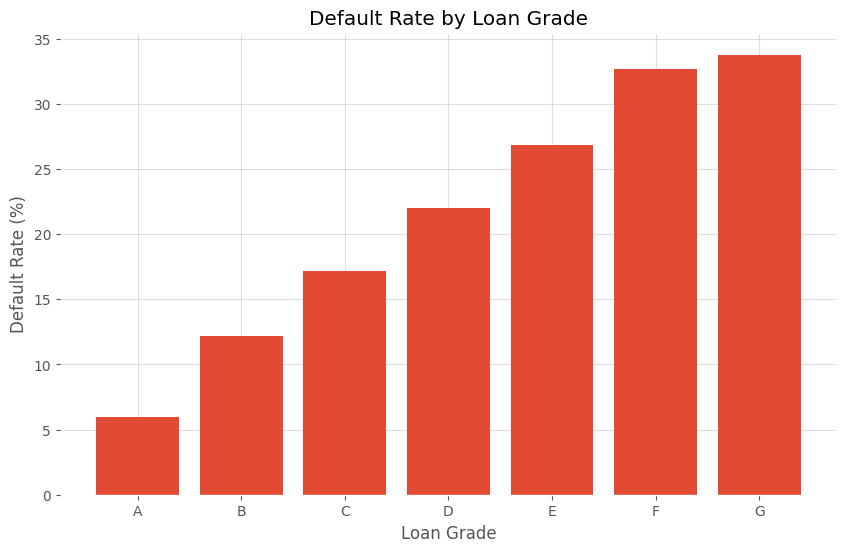

In [60]:
plt.figure(figsize=(10, 6))
plt.bar(group_by_grade_default_rate.index, group_by_grade_default_rate.values)
plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Grade')
plt.title('Default Rate by Loan Grade')

#### Question 4.2. Create a function to plot `loan_status` across `any categorical variable`.
> Hint: How did you visualise in Question 4.1? Is there a way to generalise what you did for `any categorical variable`?

In [61]:
def get_default_rate_by_col(df, col_name):
    grouped_result = (
        df
        .groupby(col_name)
        ['loan_status']
        .mean()
        .sort_values() * 100
    )
    plt.figure(figsize=(10, 6))
    plt.bar(grouped_result.index, grouped_result.values)
    plt.ylabel('Default Rate (%)')
    plt.xlabel(col_name)
    plt.title(f'Default Rate by {col_name}')

    plt.xticks(rotation=45, ha='right')

#### How's default rates across `grade` of loan? Use your newly created function :)

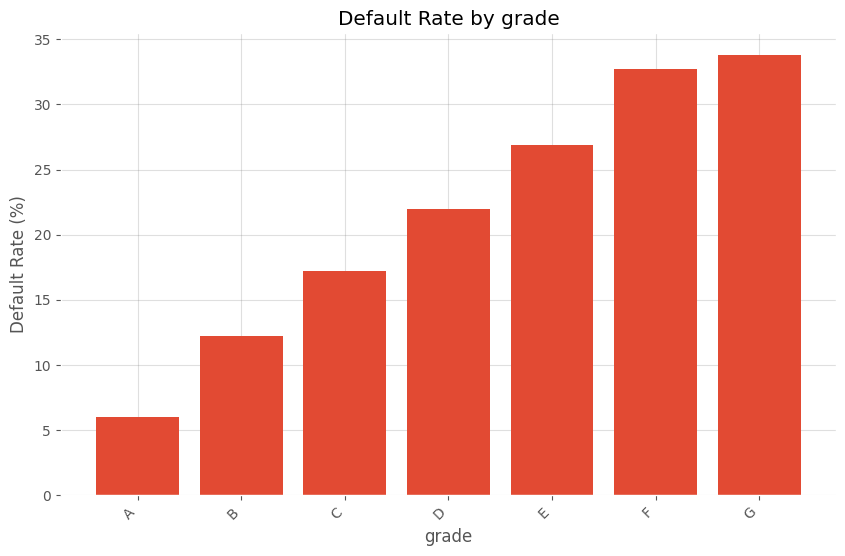

In [62]:
get_default_rate_by_col(loans_eda_without_current, 'grade')

> What is your `interpretation`? **`Double Click` and type in your interpretation here**

Observation: Default rates increase as loan grade worsens. 

Interpretation: Borrowers with lower grades are much more likely to default.

#### `term`

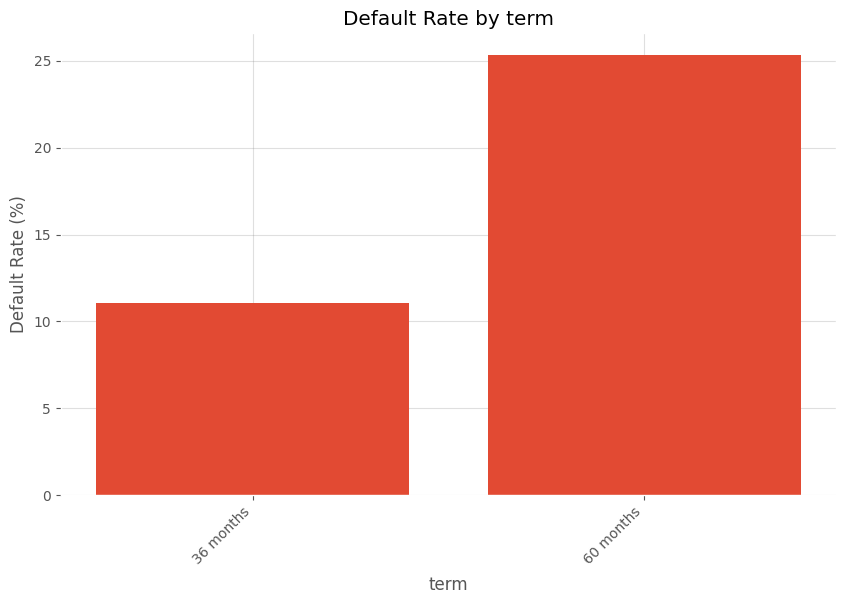

In [63]:
get_default_rate_by_col(loans_eda_without_current, 'term')

> What is your `interpretation`? **`Double Click` and type in your interpretation here**

Observation: Longer Term has higher default rate

Interpretation: Loans with longer repayment terms are more likely to default, suggesting increased risk

#### `home_ownership`

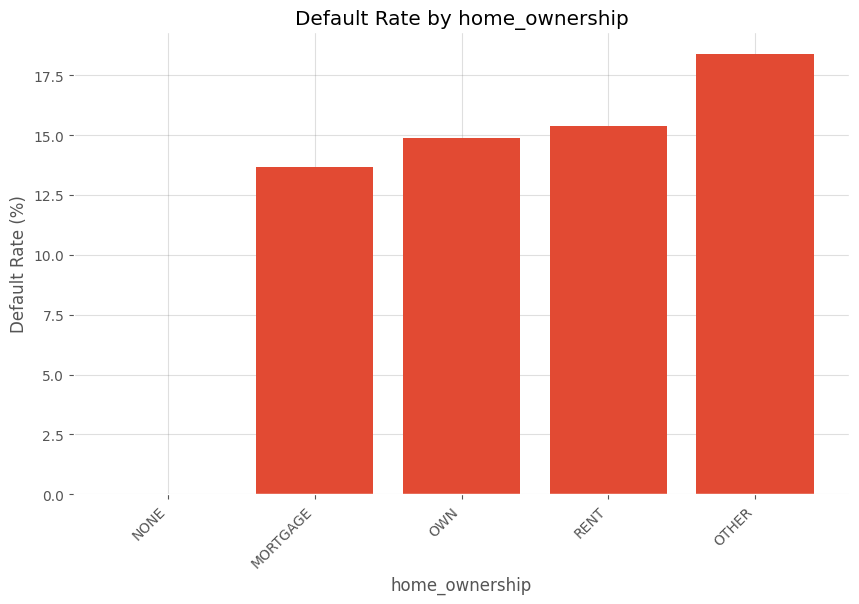

In [64]:
get_default_rate_by_col(loans_eda_without_current, 'home_ownership')

In [65]:
loans_eda_without_current.head(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,pub_rec_bankruptcies
0,5000,5000,4975.0,36 months,0.001065,162.87,B,NaN,10.0,RENT,24000.0,Verified,Dec-11,0,credit_card,27.65,0.0
1,2500,2500,2500.0,60 months,0.001527,59.83,C,Ryder,1.0,RENT,30000.0,Source Verified,Dec-11,1,car,1.00,0.0
2,2400,2400,2400.0,36 months,0.001596,84.33,C,NaN,10.0,RENT,12252.0,Not Verified,Dec-11,0,small_business,8.72,0.0
3,10000,10000,10000.0,36 months,0.001349,339.31,C,AIR RESOURCES BOARD,10.0,RENT,49200.0,Source Verified,Dec-11,0,other,20.00,0.0
5,5000,5000,5000.0,36 months,0.000790,156.46,A,Veolia Transportaton,3.0,RENT,36000.0,Source Verified,Dec-11,0,wedding,11.20,0.0


> What is your `interpretation`? **`Double Click` and type in your interpretation here**

Observation: Borrowers with “OTHER” or “RENT” home ownership show the highest default rates, while those with mortgages have the lowest.
Interpretation: Renting or ambiguous housing situations are linked to higher credit risk, whereas having a mortgage signals stronger financial stability.

#### The role of `verification_status`?

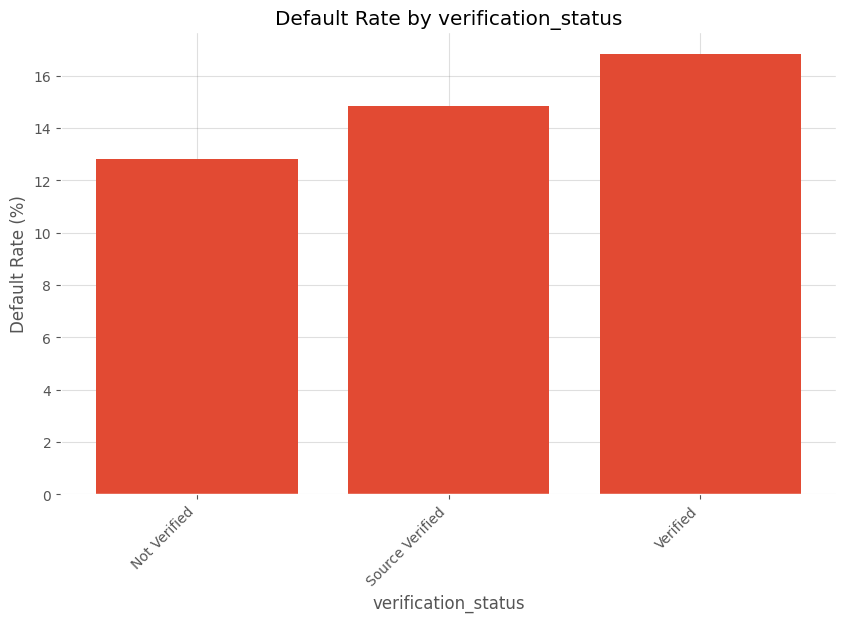

In [66]:
get_default_rate_by_col(loans_eda_without_current,'verification_status')

> What is your `interpretation`? **`Double Click` and type in your interpretation here**

Observation: Default rates rise with verification status, with Verified borrowers showing the highest default rate.
Interpretation: Income verification does not necessarily reduce credit risk, suggesting that even verified borrowers may overstate their ability to repay.

#### The role of Loan `purpose`?

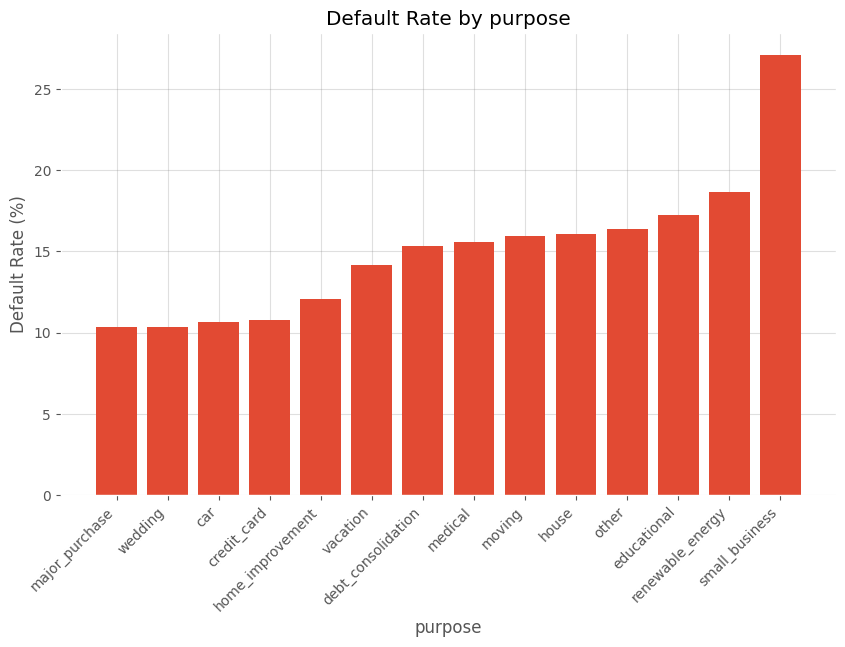

In [67]:
get_default_rate_by_col(loans_eda_without_current,'purpose')

> What is your `interpretation`? **`Double Click` and type in your interpretation here**

Observation: Default rates vary widely by loan purpose, with small business loans showing the highest default rate (~27%) and major purchases, weddings, and car loans showing the lowest (~10–11%).


Interpretation: Borrowers taking loans for riskier or less predictable ventures like small businesses or renewable energy are much more likely to default, while loans for tangible and essential purposes (cars, weddings, major purchases) carry lower credit risk.

#### Question 4.3. How is the distribution of loans across time?

> Please convert the column `issue_d` into datetime and then extract year and month from it.

> Yes, please use `lambda`.

In [68]:
loans_eda_without_current['issue_d'].value_counts()

issue_d
Nov-11    2062
Dec-11    2042
Oct-11    1941
Sep-11    1913
Aug-11    1798
Jul-11    1745
Jun-11    1728
May-11    1609
Apr-11    1559
Mar-11    1442
Jan-11    1380
Feb-11    1297
Dec-10    1267
Oct-10    1132
Nov-10    1121
Jul-10    1119
Sep-10    1086
Aug-10    1078
Jun-10    1029
May-10     920
Apr-10     827
Mar-10     737
Feb-10     627
Nov-09     602
Dec-09     598
Jan-10     589
Oct-09     545
Sep-09     449
Aug-09     408
Jul-09     374
Jun-09     356
May-09     319
Apr-09     290
Mar-09     276
Feb-09     260
Jan-09     239
Mar-08     236
Dec-08     223
Nov-08     184
Feb-08     174
Jan-08     171
Apr-08     155
Oct-08      96
Dec-07      85
Jul-08      83
May-08      71
Aug-08      71
Jun-08      66
Oct-07      47
Nov-07      37
Aug-07      33
Sep-08      32
Jul-07      30
Sep-07      18
Jun-07       1
Name: count, dtype: int64

In [69]:
loans_eda_without_current['issue_d'] = loans_eda_without_current['issue_d'].apply(lambda x: pd.to_datetime(x, format='%b-%y'))

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/1493387231.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['issue_d'] = loans_eda_without_current['issue_d'].apply(lambda x: pd.to_datetime(x, format='%b-%y'))


In [70]:
loans_eda_without_current['issue_d'].value_counts()

issue_d
2011-11-01    2062
2011-12-01    2042
2011-10-01    1941
2011-09-01    1913
2011-08-01    1798
2011-07-01    1745
2011-06-01    1728
2011-05-01    1609
2011-04-01    1559
2011-03-01    1442
2011-01-01    1380
2011-02-01    1297
2010-12-01    1267
2010-10-01    1132
2010-11-01    1121
2010-07-01    1119
2010-09-01    1086
2010-08-01    1078
2010-06-01    1029
2010-05-01     920
2010-04-01     827
2010-03-01     737
2010-02-01     627
2009-11-01     602
2009-12-01     598
2010-01-01     589
2009-10-01     545
2009-09-01     449
2009-08-01     408
2009-07-01     374
2009-06-01     356
2009-05-01     319
2009-04-01     290
2009-03-01     276
2009-02-01     260
2009-01-01     239
2008-03-01     236
2008-12-01     223
2008-11-01     184
2008-02-01     174
2008-01-01     171
2008-04-01     155
2008-10-01      96
2007-12-01      85
2008-07-01      83
2008-05-01      71
2008-08-01      71
2008-06-01      66
2007-10-01      47
2007-11-01      37
2007-08-01      33
2008-09-01      32
2007

In [71]:
loans_eda_without_current['issue_d'][0]

Timestamp('2011-12-01 00:00:00')

> Please extract month and year from `issue_d`, using `lambda`.

In [72]:
loans_eda_without_current['issue_year'] = loans_eda_without_current['issue_d'].apply(lambda x: x.year)
loans_eda_without_current['issue_month'] = loans_eda_without_current['issue_d'].apply(lambda x: x.month)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/2879237647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['issue_year'] = loans_eda_without_current['issue_d'].apply(lambda x: x.year)
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/2879237647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['issue_month'] = loans_eda_without_current['issue_d'].apply(lambda x: x.month)


> How would you examine the number of loans granted across `years`?

In [73]:
loans_per_year =\
(
    loans_eda_without_current
    .groupby('issue_year')
    .size()
)
loans_per_year

issue_year
2007      251
2008     1562
2009     4716
2010    11532
2011    20516
dtype: int64

Text(0.5, 1.0, 'Loans Issued per Year')

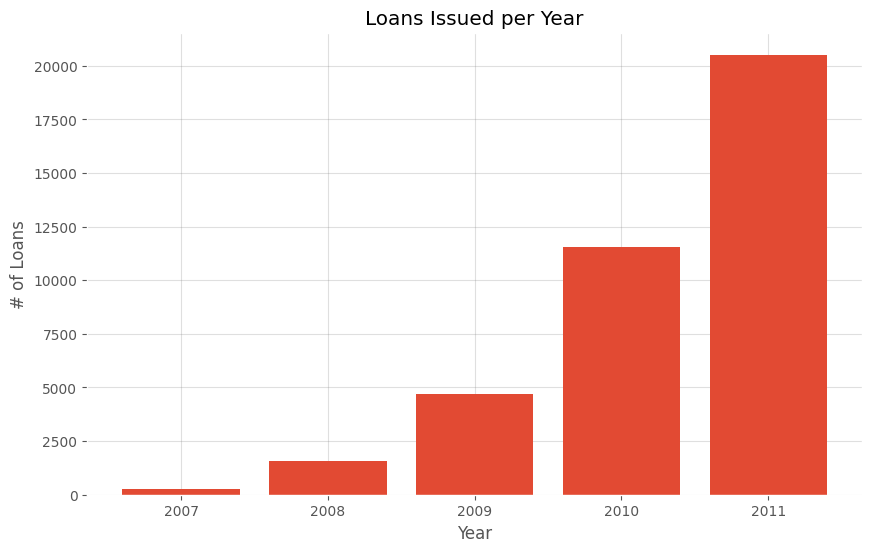

In [74]:
plt.figure(figsize=(10, 6))
plt.bar(loans_per_year.index, loans_per_year.values)
plt.ylabel('# of Loans')
plt.xlabel('Year')
plt.title('Loans Issued per Year')

You can see that the number of loans has increased steadily across years. 

> How would you examine the number of loans across months?

In [75]:
loans_by_month =\
(
    loans_eda_without_current
    .groupby('issue_month')
    .size()
)
loans_by_month

issue_month
1     2379
2     2358
3     2691
4     2831
5     2919
6     3180
7     3351
8     3388
9     3498
10    3761
11    4006
12    4215
dtype: int64

In [76]:
loans_per_year =\
(
    loans_eda_without_current
    .groupby('issue_year')
    .size()
)

`Interpretation`?

Observation: The number of loans issued increases steadily throughout the year, peaking in December and lowest in January–February.

Interpretation: Loan demand is seasonal, with stronger borrowing activity toward year-end—possibly driven by holiday spending, business cash flow needs, and year-end financial planning.

#### Compare the default rates across years.

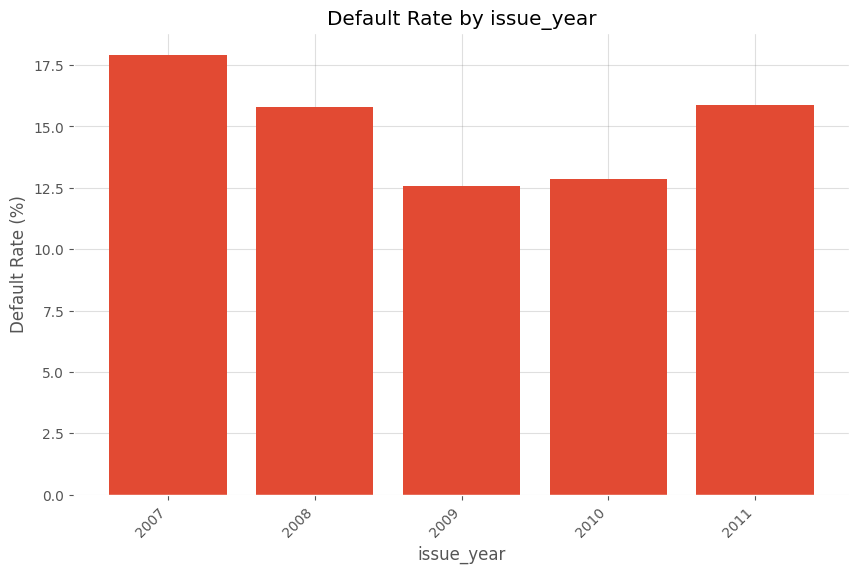

In [77]:
get_default_rate_by_col(loans_eda_without_current, 'issue_year')

> `Interpretation`?

Observation: Default rates were highest for loans issued in 2007 (~18%) and declined through 2009–2010 (~12–13%), before rising again in 2011 (~16%).


Interpretation: In 2007, few loans were issued but defaults were relatively high, possibly due to immature borrower screening. By 2011, although default rates only fell slightly, the sheer volume of loans grew exponentially, amplifying overall credit risk.

#### Let's compare default rates across months.

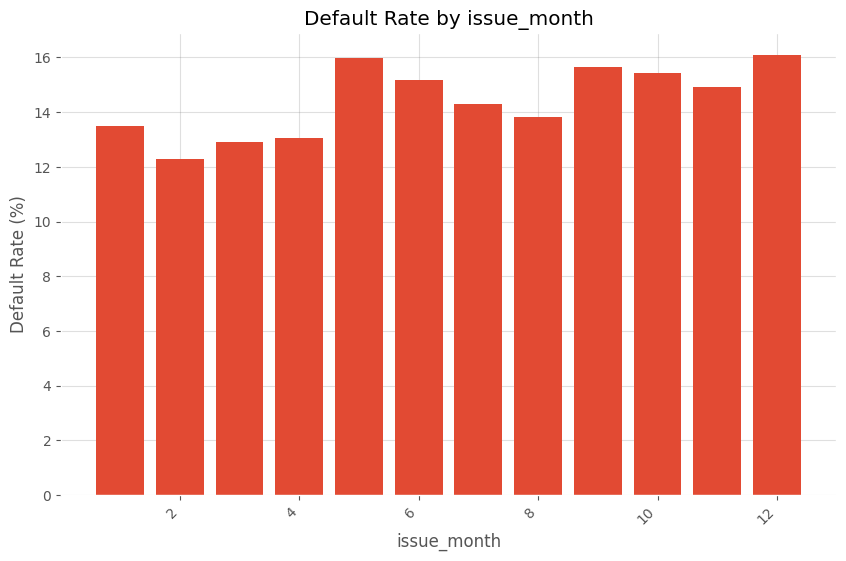

In [78]:
get_default_rate_by_col(loans_eda_without_current, 'issue_month')

> `Interpretation`? 

Observation: Default rates are lower in the early months of the year (~12–13%) but gradually rise, peaking around May and December (~16%).

Interpretation: Seasonality appears to influence defaults, with borrowers taking loans mid-year and at year-end more likely to default—possibly due to higher spending during summer and holiday periods, while loans issued earlier in the year show slightly lower risk.


#### Question 4.4. Let's now analyse how the default rate varies across continuous variables.

> Loan Amount: `loan_amnt`

In [ ]:
# Plot default rate by loan amount bins (histogram-style)
get_default_rate_by_col(loans_eda_without_current, 'loan_amnt')

#  check what to populate here


NameError: name 'get_default_rate_by_col' is not defined

> `Interpretation`?

Observation: Default rates are lower for smaller loans (<$10k, ~12–14%) and steadily increase with loan size, reaching the highest levels (~24–25%) for loans above $30k.

Interpretation: Larger loan amounts are associated with higher risk, as bigger repayment burdens make defaults more likely, while smaller loans are comparatively safer for lenders.

> Another way to analyse how default rates vary across continous variables is to bin the variables into discrete categories.

> Let's create a categorical variable for the loan amount variable into small, medium, high, very high.

* loan_amount < 5000 `low`
* loan_amount >=5000 and loan_amount < 15000 `medium`
* loan_amount >= 15000 and loan_amount < 25000 `high`
* greater than 25000 `very high`

In [80]:
loans_eda_without_current['loan_amnt'].describe()

count    38577.000000
mean     11047.025430
std       7348.441646
min        500.000000
25%       5300.000000
50%       9600.000000
75%      15000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

In [81]:
bins = [0, 5000, 15000, 25000, np.inf]
labels = ['low', 'medium', 'high', 'very high']

loans_eda_without_current['loan_amnt_bin'] = pd.cut(loans_eda_without_current['loan_amnt'], bins=bins, labels=labels, right=True)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/2221071716.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['loan_amnt_bin'] = pd.cut(loans_eda_without_current['loan_amnt'], bins=bins, labels=labels, right=True)


In [82]:
help(pd.cut)

Help on function cut in module pandas.core.reshape.tile:

cut(x, bins, right: 'bool' = True, labels=None, retbins: 'bool' = False, precision: 'int' = 3, include_lowest: 'bool' = False, duplicates: 'str' = 'raise', ordered: 'bool' = True)
    Bin values into discrete intervals.

    Use `cut` when you need to segment and sort data values into bins. This
    function is also useful for going from a continuous variable to a
    categorical variable. For example, `cut` could convert ages to groups of
    age ranges. Supports binning into an equal number of bins, or a
    pre-specified array of bins.

    Parameters
    ----------
    x : array-like
        The input array to be binned. Must be 1-dimensional.
    bins : int, sequence of scalars, or IntervalIndex
        The criteria to bin by.

        * int : Defines the number of equal-width bins in the range of `x`. The
          range of `x` is extended by .1% on each side to include the minimum
          and maximum values of `x`.
    

> Let's compare the default rates across loan amount type

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/2139189208.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col_name)


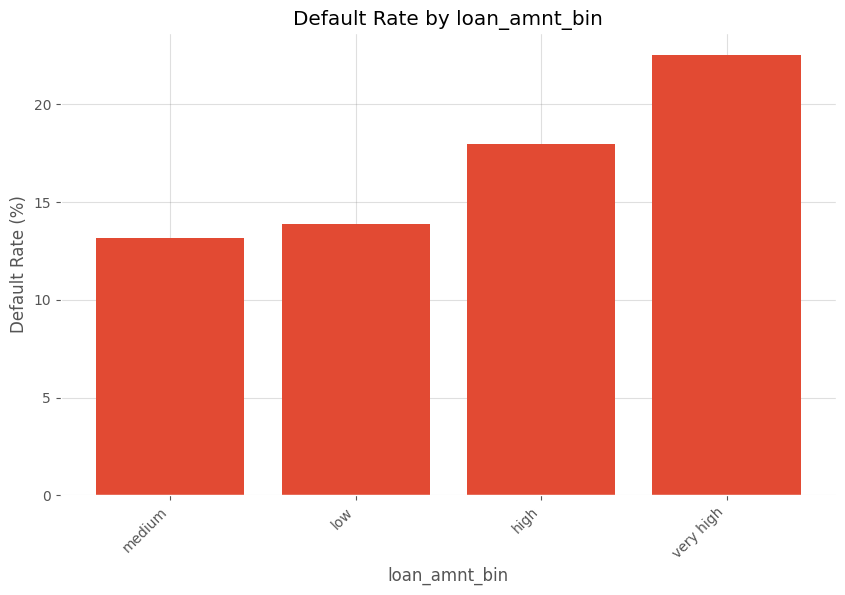

In [83]:
get_default_rate_by_col(loans_eda_without_current, 'loan_amnt_bin')

In [84]:
loans_eda_without_current['loan_amnt_bin'].value_counts()

loan_amnt_bin
medium       20485
low           9472
high          7185
very high     1435
Name: count, dtype: int64

> `Interpretation`?

Observation: Default rates increase with loan amount, starting around 13–14% for loans under $15k and rising sharply to over 22% for loans above $25k.

Interpretation: Larger loans carry higher repayment burdens and thus greater risk of default, suggesting loan size is a key factor in credit risk assessment.

#### Let's also convert funded amount invested to bins (using the same scheme from `loan_amount`)

In [85]:
loans_eda_without_current['funded_amnt_bin'] = pd.cut(loans_eda_without_current['funded_amnt'], bins=bins, labels=labels, right=True)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/1261108673.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['funded_amnt_bin'] = pd.cut(loans_eda_without_current['funded_amnt'], bins=bins, labels=labels, right=True)


> Visualize the results

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/2139189208.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col_name)


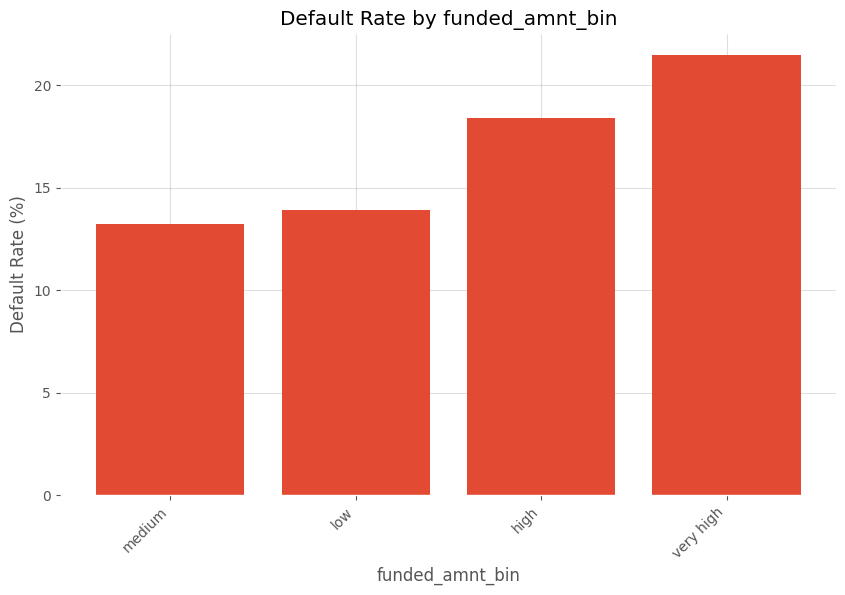

In [86]:
get_default_rate_by_col(loans_eda_without_current, 'funded_amnt_bin')

#### Interest Rate (int_rate)

> Use the following definitions for each categories.

* <= 10 `low`
* dti > 10 and dti <=15 `medium`
* greater than 15 `high`

> Use lambda for creating a new categorical variable.

In [87]:
(loans_eda_without_current['int_rate']*100).describe()

count    38577.000000
mean         0.119322
std          0.036913
min          0.054200
25%          0.089400
50%          0.117100
75%          0.143800
max          0.244000
Name: int_rate, dtype: float64

In [88]:
loans_eda_without_current['int_rate_category'] = loans_eda_without_current['int_rate'].apply(
    lambda x: 'low' if x*100 <= 0.1 else ('medium' if x*100 <= 0.15 else 'high')
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/3504353829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['int_rate_category'] = loans_eda_without_current['int_rate'].apply(


> Let's compare default rates across rates of interest

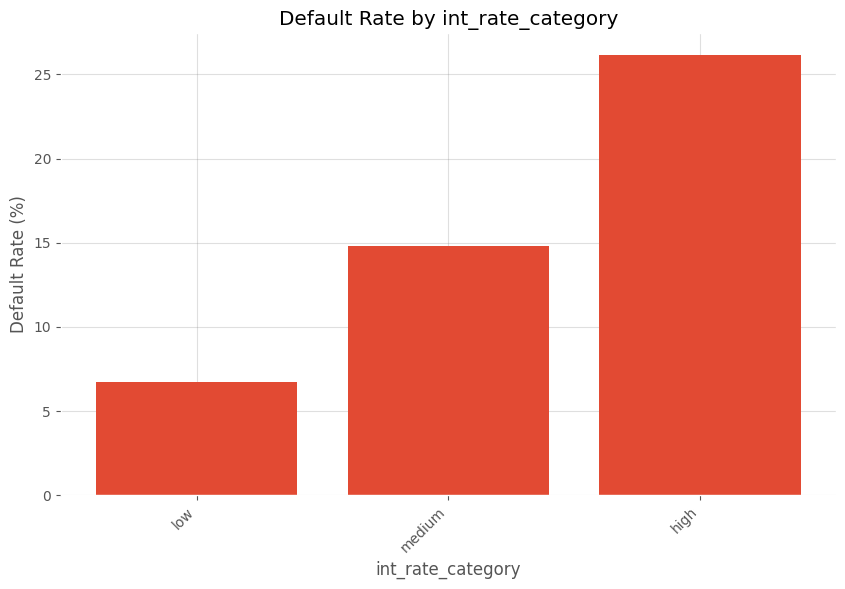

In [89]:
get_default_rate_by_col(loans_eda_without_current, 'int_rate_category')

> `Interpretaion`?

Observation: Default rates rise sharply with interest rate levels — about 6–7% for low-rate loans, ~15% for medium-rate loans, and ~26% for high-rate loans.

Interpretation: Higher interest rates strongly correlate with higher default risk, reflecting that riskier borrowers are charged higher rates, and these borrowers are indeed more likely to default.


#### debt-to-income (`dti`) ratio

> Please create a categorical variable of `dti` using your own function

> Use the following definitions for each categories.

* <= 10 `low`
* dti > 10 and dti <=20 `medium`
* greater than 20 `high`

> Use lambda for creating a new variable.

In [90]:
loans_eda_without_current['dti'].describe()

count    38577.000000
mean        13.272727
std          6.673044
min          0.000000
25%          8.130000
50%         13.370000
75%         18.560000
max         29.990000
Name: dti, dtype: float64

In [91]:
loans_eda_without_current['dti_category'] = loans_eda_without_current['dti'].apply(
    lambda x: 'low' if x <= 10 else ('medium' if x <= 20 else 'high')
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/3474159537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['dti_category'] = loans_eda_without_current['dti'].apply(


> Let's comparing default rates across debt to income ratio

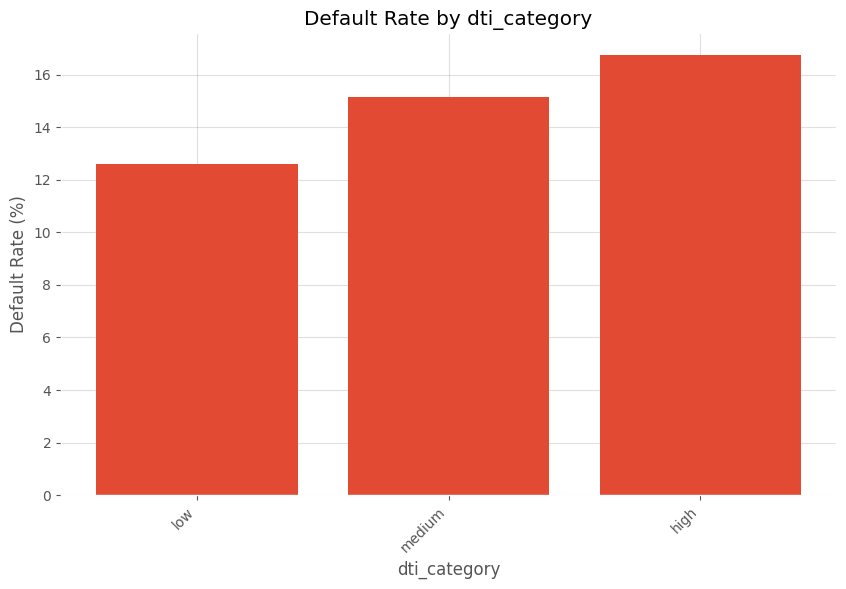

In [92]:
get_default_rate_by_col(loans_eda_without_current, 'dti_category')

> `Interpretation`?

Observation: Default rates rise steadily with higher debt-to-income levels — ~12.5% for low (≤10), ~15% for medium (10–15), and ~16–17% for high (>15).

Interpretation: Borrowers with heavier debt obligations relative to income are more likely to default, showing that higher DTI directly reduces repayment ability and elevates credit risk.

#### `funded_amount`

> Please create a categorical variable of `funded_amount` using your own function

> Use the following definitions for each categories.

- <= 5000 `low`
- funded_amount > 5000 and funded_amount <=15000 `medium`
- greater than 15000 `high`

> Use lambda for creating a new variable.

In [93]:
loans_eda_without_current['funded_amnt']

0         5000
1         2500
2         2400
3        10000
5         5000
         ...  
39712     2500
39713     8500
39714     5000
39715     5000
39716     7500
Name: funded_amnt, Length: 38577, dtype: int64

In [94]:
loans_eda_without_current['funded_amt_category'] = loans_eda_without_current['funded_amnt'].apply(
    lambda x: 'low' if x <= 5000 else ('medium' if x <= 15000 else 'high')
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/3115680098.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['funded_amt_category'] = loans_eda_without_current['funded_amnt'].apply(


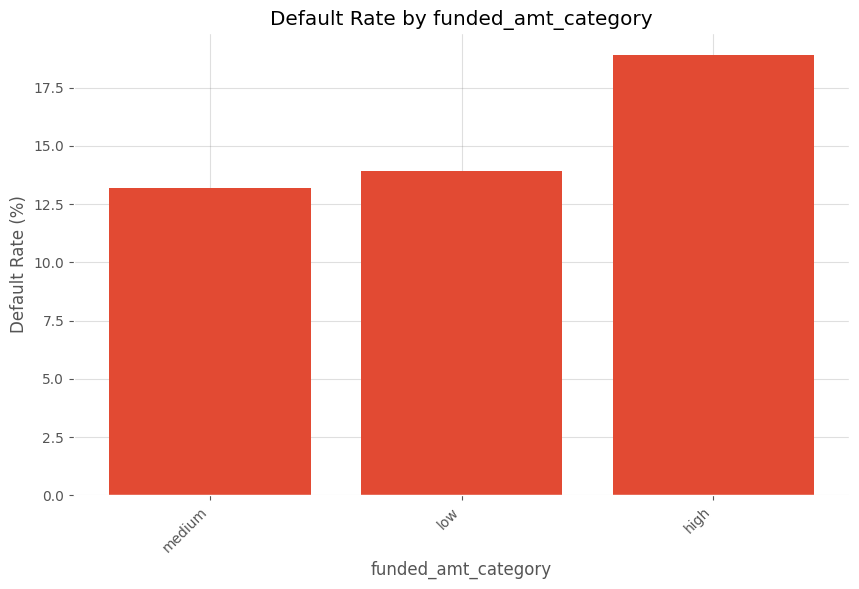

In [95]:
get_default_rate_by_col(loans_eda_without_current, 'funded_amt_category')

#### `installment`

> Please create a categorical variable of `installment` using your own function

> Use the following definitions for each categories.

- installment <= 200 `low`
- installment > 200 and installment <= 400 `medium`
- installment > 400 and installment <= 600 `high`
- greater than 600 = `very high`

> Use lambda for creating a new variable.

In [96]:
def categorize_installment(x):
    if x <= 200:
        return 'low'
    elif x <= 400:
        return 'medium'
    elif x <= 600:
        return 'high'
    else:
        return 'very high'

In [97]:
loans_eda_without_current['installment_category'] = loans_eda_without_current['installment'].apply(lambda x: categorize_installment(x))

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/3531940217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['installment_category'] = loans_eda_without_current['installment'].apply(lambda x: categorize_installment(x))


> Let's compare default rates across installment

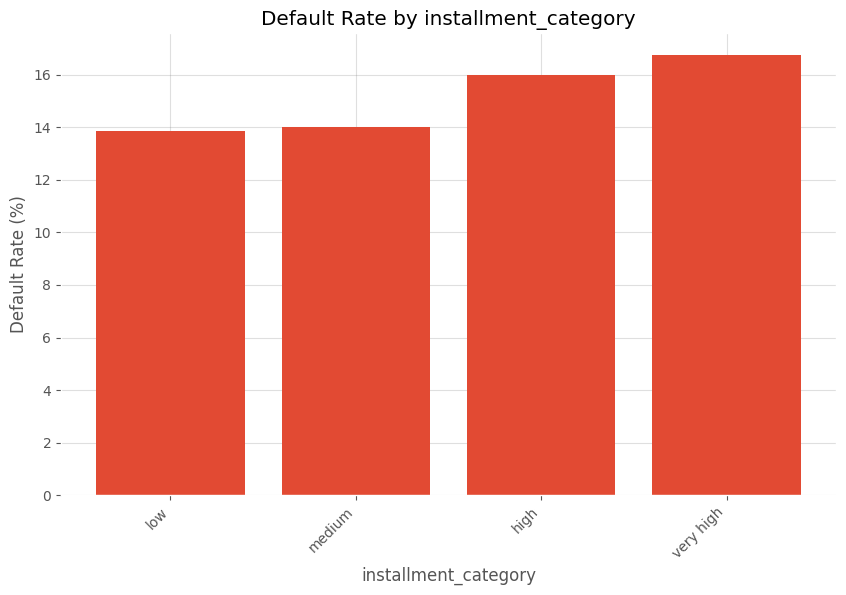

In [98]:
get_default_rate_by_col(loans_eda_without_current, 'installment_category')

> `Interpretation`?

Observation: Default rates increase steadily as installment amounts rise — ~14% for low/medium installments, ~16% for high, and ~17% for very high.

Interpretation: Borrowers with larger monthly installments face heavier repayment burdens, leading to a higher likelihood of default compared to those with smaller installments.


#### How about `annual_income`? 

> Please create a categorical variable of annual_income using your own function

> Use the following definitions for each categories.

- less than or equal to 50k = `low`
- greater than 50k less than equal to 100 k = `medium`
- greater than 100k less than equal to 150k = `high`
- greater than 150k = `very high`

> Use lambda for creating a new variable.

In [99]:
def categorize_annual_income(x):
    if x <= 50_000:
        return 'low'
    elif x <= 100_000:
        return 'medium'
    elif x <= 150_000:
        return 'high'
    else:
        return 'very high'

In [100]:
loans_eda_without_current['annual_inc_category'] = loans_eda_without_current['annual_inc'].apply(lambda x: categorize_annual_income(x))

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/3448833587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['annual_inc_category'] = loans_eda_without_current['annual_inc'].apply(lambda x: categorize_annual_income(x))


> Visualize the results.

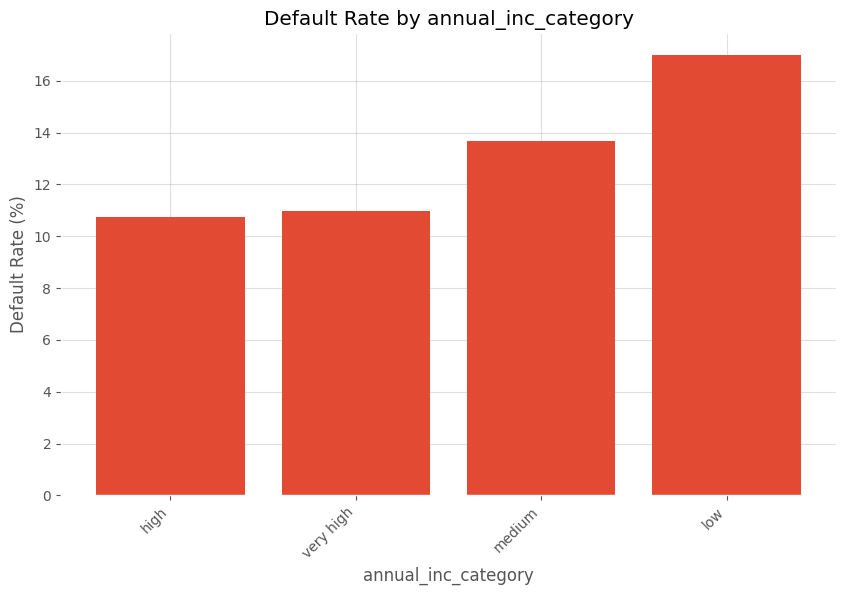

In [101]:
get_default_rate_by_col(loans_eda_without_current, 'annual_inc_category')

> What's your interpretation?

Observation: Default rates are highest among borrowers with low annual income (~17%), decreasing steadily for medium (~14%), high (~11%), and very high (~11%) income groups.

Interpretation: Borrowers with lower annual income face greater repayment challenges, leading to more defaults, while higher-income borrowers are more resilient, showing significantly lower default risk.


#### `Employment Length`

> First, let's drop the missing value observations in `emp_length`

In [102]:
loans_eda_emp_length_dropped =\
(
    loans_eda_without_current
    .dropna(subset=['emp_length'])
)

In [103]:
loans_eda_emp_length_dropped['emp_length'].describe()

count    37544.000000
mean         5.061048
std          3.401750
min          1.000000
25%          2.000000
50%          4.000000
75%          9.000000
max         10.000000
Name: emp_length, dtype: float64

> Please create a categorical variable of `emp_length` using your own function

> Use the following definitions for each categories.

* emp_length <= 1 `fresher`
* emp_length > 1 and emp_length <=3 `junior`
* emp_length > 3 and emp_length <=7 `senior`
* greater than 7 `expert`

> Use lambda for creating a new variable.

In [104]:
def categorize_emp_length(x):
    if x <= 1:
        return 'fresher'
    elif x <= 3:
        return 'junior'
    elif x <= 7:
        return 'senior'
    else:
        return 'expert'

In [105]:
loans_eda_emp_length_dropped['emp_length_category'] = loans_eda_emp_length_dropped['emp_length'].apply(categorize_emp_length)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/635903415.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_emp_length_dropped['emp_length_category'] = loans_eda_emp_length_dropped['emp_length'].apply(categorize_emp_length)


> Visualize the results

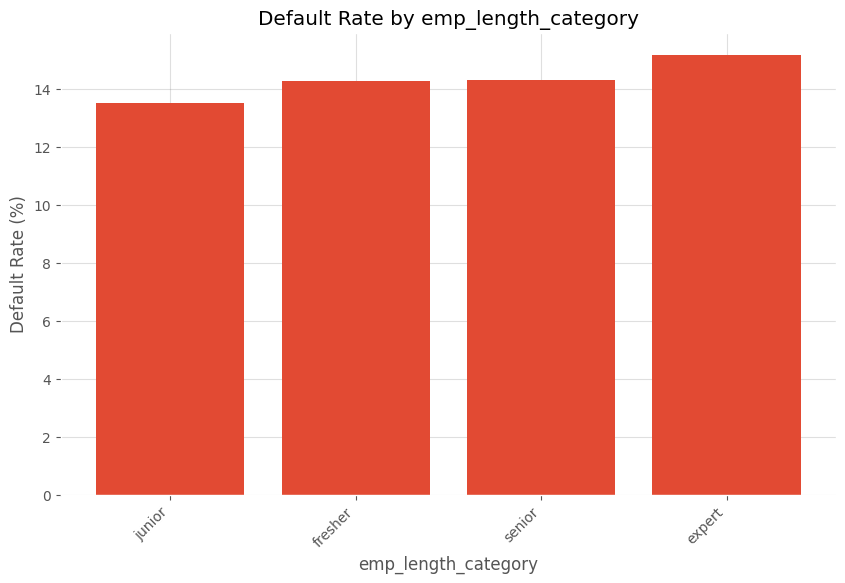

In [106]:
get_default_rate_by_col(loans_eda_emp_length_dropped, 'emp_length_category')

> What's your `interetation`?

Observation: Default rates rise gradually with employment length — ~13.5% for junior employees, ~14–14.5% for freshers and seniors, and the highest (~15%) for experts.

Interpretation: Longer employment history does not guarantee lower credit risk; in fact, defaults are slightly higher among borrowers with long tenures, possibly because larger or riskier loans are extended to them due to perceived stability.


### Question 5. Segmented Univariate Analysis



#### Question 5.1. A quick glance on Loan Purpose (`purpose`) using your first function :)

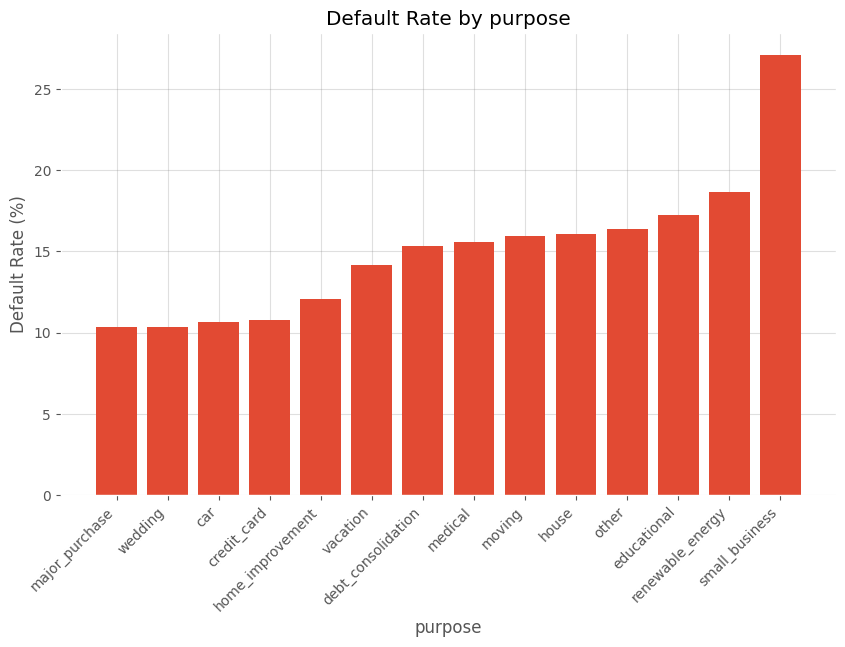

In [107]:
get_default_rate_by_col(loans_eda_without_current,'purpose')

`Interpretation`?

#### Question 5.2. Now let's segment the loan applications across the purpose of the loan, since that is a variable affecting many other variables - the type of applicant, interest rate, income, and finally the default rate. 

> Let's take a look at the number of loans for each type (purpose) of the loan.

In [108]:
loans_eda_without_current['purpose'].unique()

array(['credit_card', 'car', 'small_business', 'other', 'wedding',
       'debt_consolidation', 'home_improvement', 'major_purchase',
       'medical', 'moving', 'vacation', 'house', 'renewable_energy',
       'educational'], dtype=object)

In [109]:
(
    loans_eda_without_current['purpose']
    .value_counts()
    .sort_values(ascending=False)
)

purpose
debt_consolidation    18055
credit_card            5027
other                  3865
home_improvement       2875
major_purchase         2150
small_business         1754
car                    1499
wedding                 926
medical                 681
moving                  576
vacation                375
house                   367
educational             325
renewable_energy        102
Name: count, dtype: int64

> Please analyze the top 4 types of loans based on purpose

Debt Consolidation: Most common purpose; helps borrowers roll multiple debts into one, but carries relatively high default risk since borrowers are already financially strained.

Credit Card: Second most common; mainly for refinancing credit card balances, slightly safer than general debt consolidation but still default-prone.

Other: A catch-all category with varied loan uses; riskier because of the lack of clear purpose and higher uncertainty.

Home Improvement: Popular for renovations; defaults are lower, making it a comparatively safer category.


#### Let's filter the df for the 4 types of loans mentioned above

In [110]:
top_4_purposes =\
(
    loans_eda_without_current['purpose']
    .value_counts()
    .sort_values(ascending=False)
    .head(4)
    .index.
    to_list()
)
top_4_purposes

['debt_consolidation', 'credit_card', 'other', 'home_improvement']

In [111]:
loans_top_4 =\
(
    loans_eda_without_current[loans_eda_without_current['purpose'].isin(top_4_purposes)]
)

In [112]:
loans_top_4

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,...,pub_rec_bankruptcies,issue_year,issue_month,loan_amnt_bin,funded_amnt_bin,int_rate_category,dti_category,funded_amt_category,installment_category,annual_inc_category
0,5000,5000,4975.0,36 months,0.001065,162.87,B,NaN,10.0,RENT,...,0.0,2011,12,low,low,medium,high,low,low,low
3,10000,10000,10000.0,36 months,0.001349,339.31,C,AIR RESOURCES BOARD,10.0,RENT,...,0.0,2011,12,medium,medium,medium,medium,medium,medium,low
6,7000,7000,7000.0,60 months,0.001596,170.08,C,Southern Star Photography,8.0,RENT,...,0.0,2011,12,medium,medium,high,high,medium,low,low
9,5375,5375,5350.0,60 months,0.001269,121.45,B,Starbucks,1.0,RENT,...,0.0,2011,12,medium,medium,medium,medium,medium,low,low
10,6500,6500,6500.0,60 months,0.001465,153.45,C,Southwest Rural metro,5.0,OWN,...,0.0,2011,12,medium,medium,medium,medium,medium,low,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,2500,2500,1075.0,36 months,0.000807,78.42,A,FiSite Research,4.0,MORTGAGE,...,NaN,2007,7,low,low,low,medium,low,low,high
39713,8500,8500,875.0,36 months,0.001028,275.38,C,"Squarewave Solutions, Ltd.",3.0,RENT,...,NaN,2007,7,medium,medium,medium,low,medium,medium,low
39714,5000,5000,1325.0,36 months,0.000807,156.84,A,NaN,1.0,MORTGAGE,...,NaN,2007,7,low,low,low,low,low,low,medium
39715,5000,5000,650.0,36 months,0.000743,155.38,A,NaN,1.0,MORTGAGE,...,NaN,2007,7,low,low,low,low,low,low,very high


#### Visualize the number of loans by purpose 

Text(0.5, 1.0, 'Loans by Top 4 Purposes')

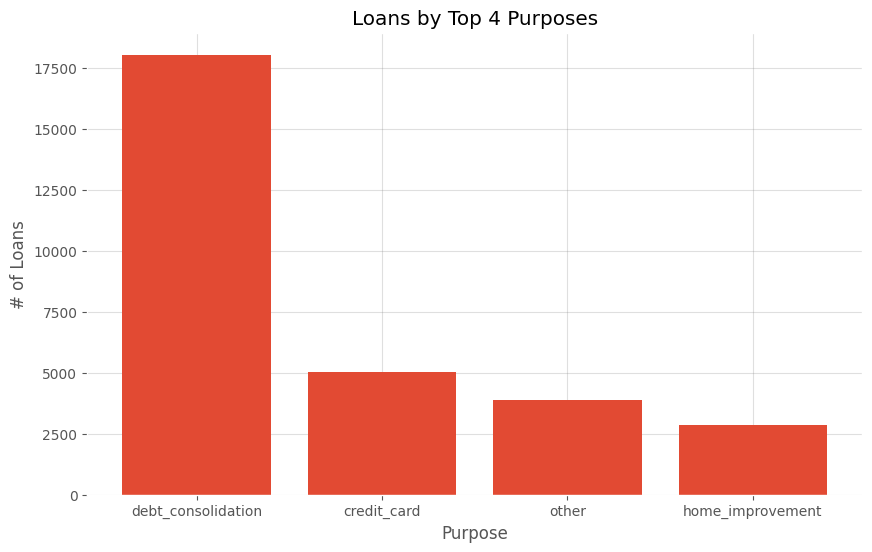

In [113]:
plt.figure(figsize=(10, 6))
plt.bar(
    loans_top_4['purpose'].value_counts().index,
    loans_top_4['purpose'].value_counts().values
)
plt.ylabel('# of Loans')
plt.xlabel('Purpose')
plt.title('Loans by Top 4 Purposes')

> let's now compare the default rates (`loan_status`) across two types of categorical variables;
> - `purpose` of loan (constant)
> - another categorical variable (which changes)

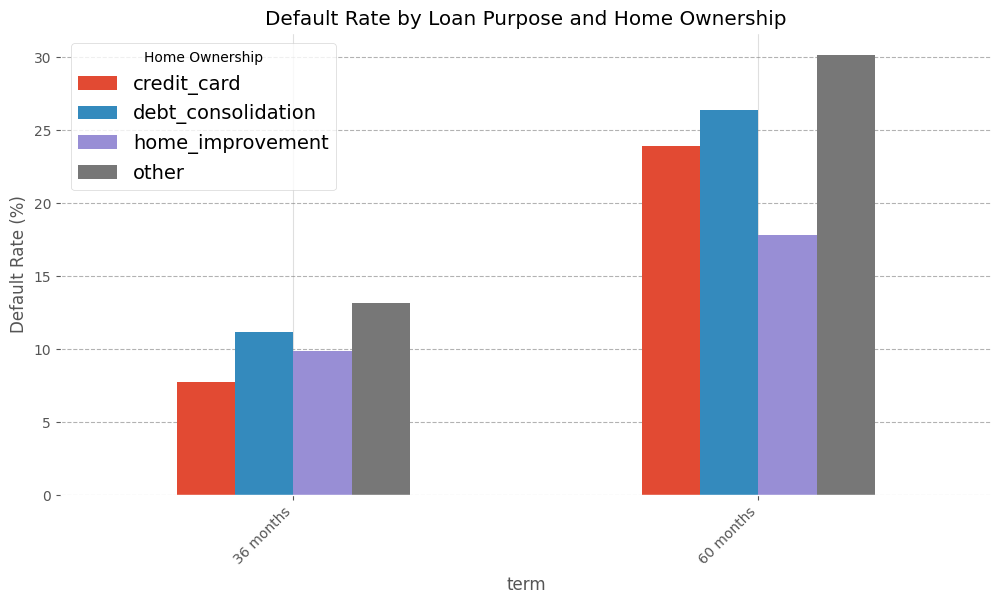

In [114]:
cross_default = (
    loans_top_4
    .groupby(['term','purpose'])['loan_status']
    .mean() * 100
)

cross_default = cross_default.unstack()

cross_default.plot(kind='bar', figsize=(12,6))
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Purpose and Home Ownership")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Home Ownership")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

> You should be able to write your own function which takes a categorical variable and plots the default rate segmented by purpose.

> Please **create your function** named `plot_segmented`

In [115]:
def plot_segmented(df, segment_col):
    cross_default = (
        df
        .groupby([segment_col, 'purpose'])['loan_status']
        .mean() * 100
    )
    cross_default = cross_default.unstack()

    cross_default.plot(kind='bar', figsize=(12,6))
    plt.ylabel("Default Rate (%)")
    plt.title(f"Default Rate by Purpose and {segment_col}")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=segment_col)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

> Let's use the function to see if there's differences in the term.

#### Grade of Loan (`grade`)

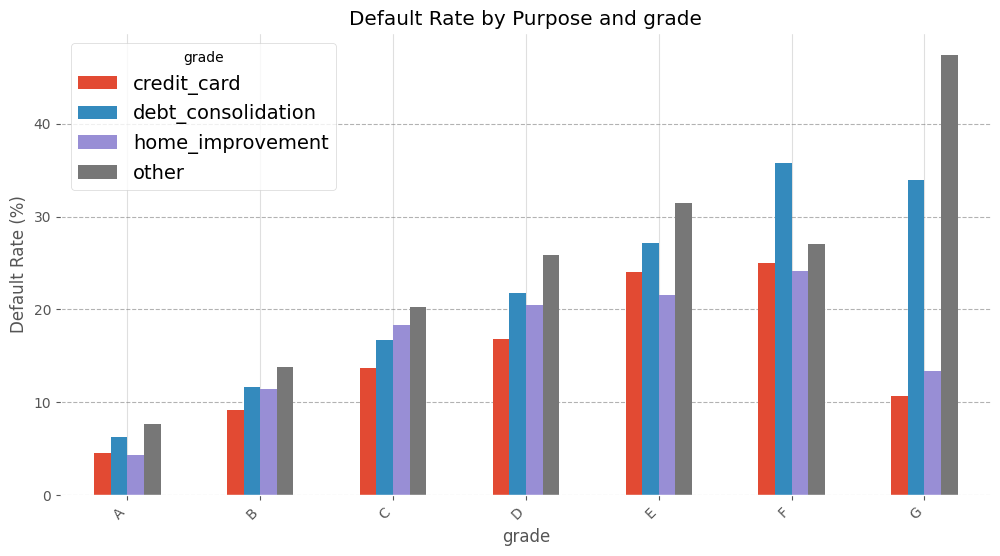

In [116]:
plot_segmented(loans_top_4, 'grade')

#### home ownership(`home_ownership`)

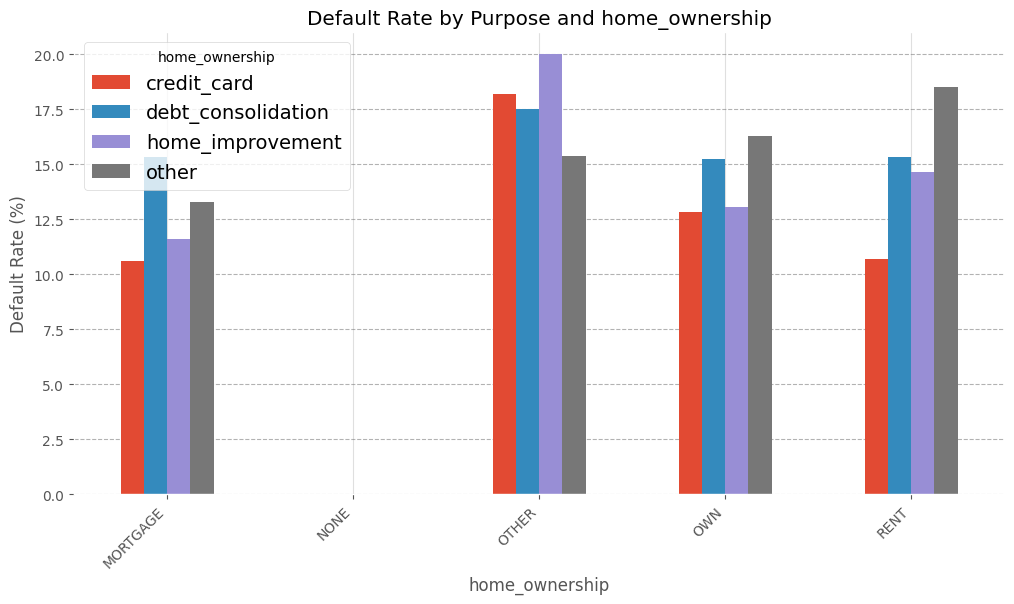

In [117]:
plot_segmented(loans_top_4, 'home_ownership')

#### `year`

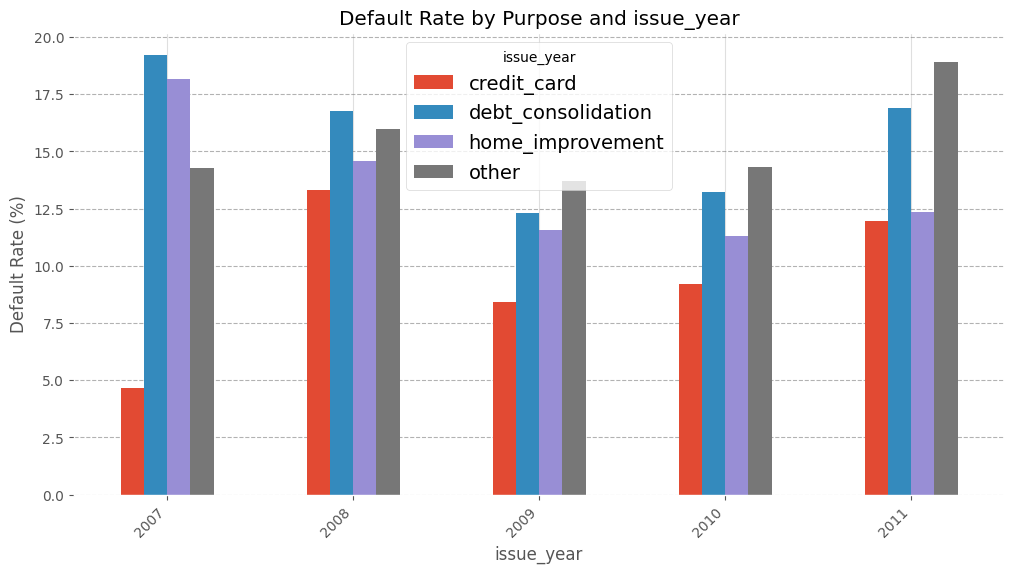

In [118]:
plot_segmented(loans_top_4, 'issue_year')

#### `emp_length`

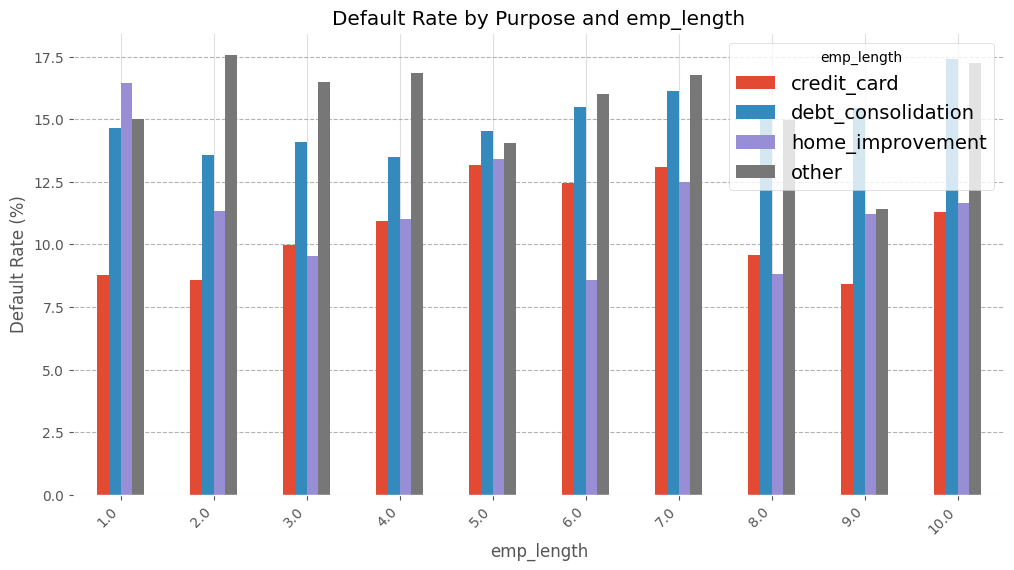

In [119]:
plot_segmented(loans_top_4, 'emp_length')

> Loan Amount (`loan_amnt`) 

> How's the pattern compared with loan purposes?

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/1764169929.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([segment_col, 'purpose'])['loan_status']


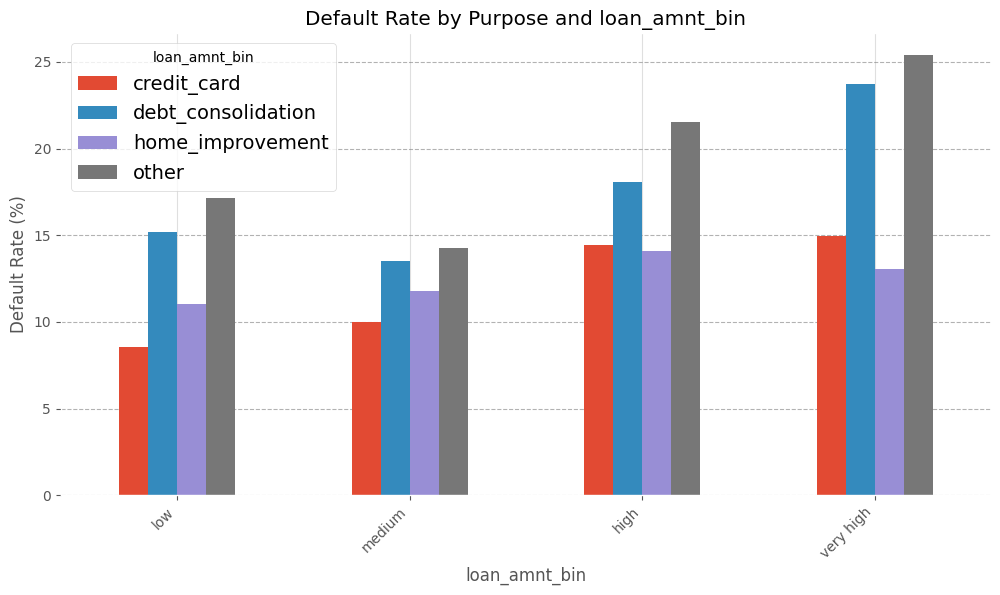

In [120]:
plot_segmented(loans_top_4, 'loan_amnt_bin')

> interest rate (`int_rate`)

In [121]:
loans_top_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29822 entries, 0 to 39716
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   loan_amnt             29822 non-null  int64         
 1   funded_amnt           29822 non-null  int64         
 2   funded_amnt_inv       29822 non-null  float64       
 3   term                  29822 non-null  object        
 4   int_rate              29822 non-null  float64       
 5   installment           29822 non-null  float64       
 6   grade                 29822 non-null  object        
 7   emp_title             28238 non-null  object        
 8   emp_length            29072 non-null  float64       
 9   home_ownership        29822 non-null  object        
 10  annual_inc            29822 non-null  float64       
 11  verification_status   29822 non-null  object        
 12  issue_d               29822 non-null  datetime64[ns]
 13  loan_status          

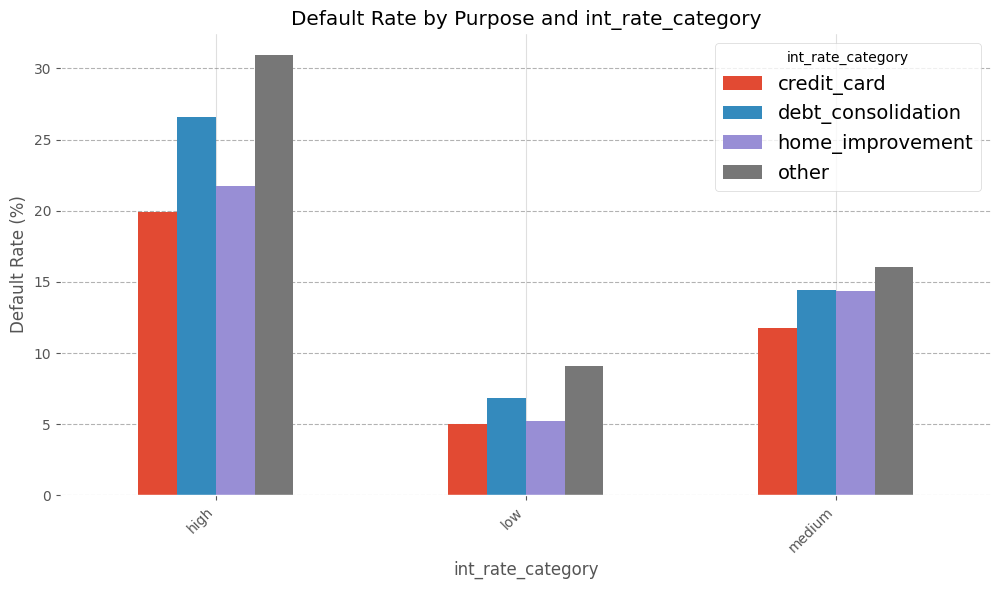

In [122]:
plot_segmented(loans_top_4, 'int_rate_category')

> `installment`

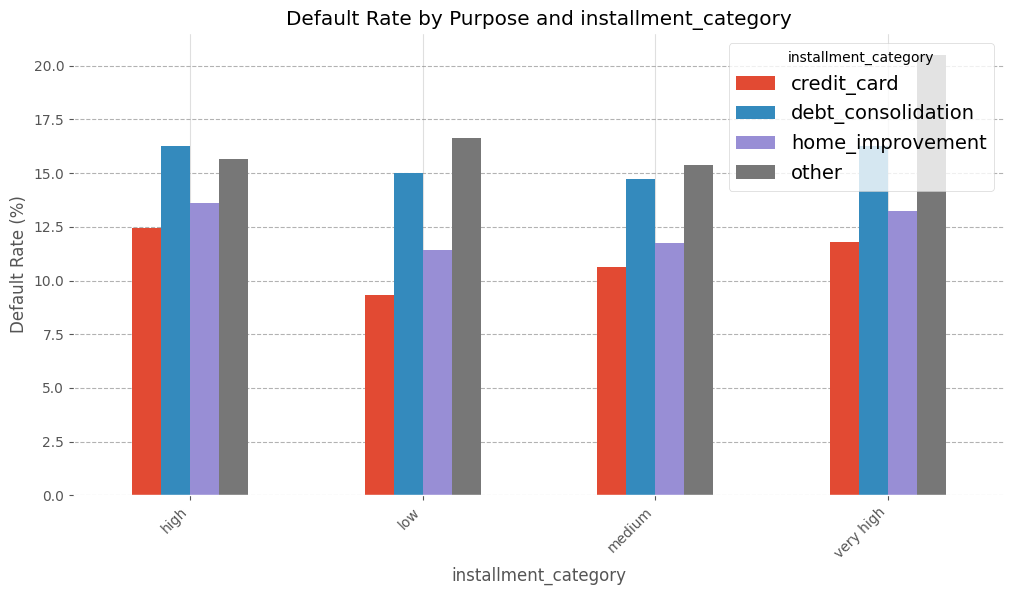

In [123]:
plot_segmented(loans_top_4, 'installment_category')

> debt-to-income (`dti`) ratio

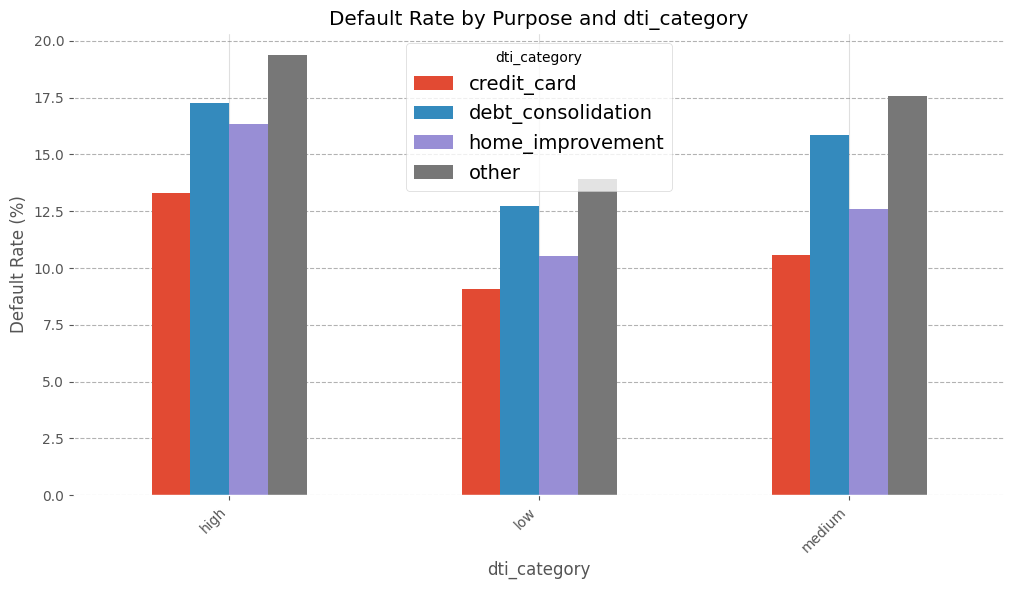

In [124]:
plot_segmented(loans_top_4, 'dti_category')

> Let's have a look at the role of `annual_income`

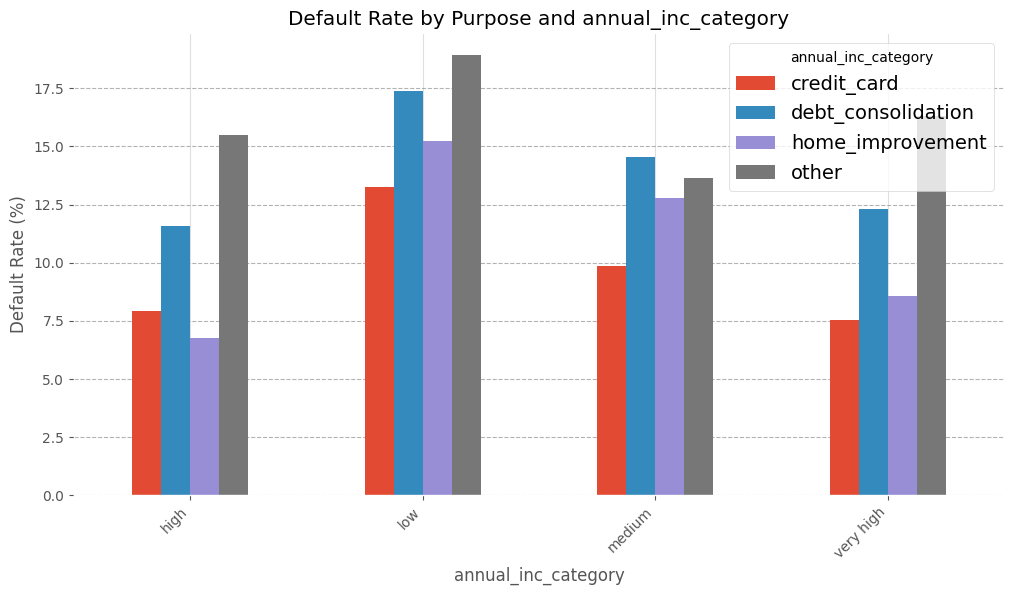

In [125]:
plot_segmented(loans_top_4, 'annual_inc_category')

> A good way to quantify the effect of a categorical variable on default rate is to see `how much does the default rate vary across the categories`. 

> Let's see an example using `annual_inc` as the categorical variable.

> How would you examine the variation of default rate across `annual_inc`?

In [126]:
default_rate_by_annual_inc =\
(
    loans_top_4
    .groupby('annual_inc_category')
    ['loan_status']
    .mean()
)

In [127]:
default_rate_by_annual_inc

annual_inc_category
high         0.105179
low          0.168313
medium       0.134632
very high    0.111986
Name: loan_status, dtype: float64

In [128]:
variation_range = default_rate_by_annual_inc.max() - default_rate_by_annual_inc.min()
print(f"Variation (Range): {variation_range*100:.2f}%")

Variation (Range): 6.31%


In [129]:
variation_std = default_rate_by_annual_inc.std()
print(f"Variation (Std Dev): {variation_std*100:.2f}%")

Variation (Std Dev): 2.85%


#### Question 5.3 Write a function which takes in a categorical variable and computed the average default rate across the categories.

> You can also compute the `difference between the highest and the lowest default rate` across the categories, which is a decent metric indicating the effect of the varaible on default rate.

> Please create your own function named `diff_rate`.

In [130]:
def diff_rate(df, cat_var):

    rates = df.groupby(cat_var)['loan_status'].mean() * 100
    
    # Compute the difference between max and min rates
    diff = rates.max() - rates.min()
    
    print(f"\nDefault Rates by {cat_var}:")
    print(rates)
    print(f"\nDifference between highest and lowest default rate: {diff:.2f}%")
    return rates, diff
    

In [131]:
rates, diff = diff_rate(loans_top_4, 'annual_inc_category')


Default Rates by annual_inc_category:
annual_inc_category
high         10.517903
low          16.831343
medium       13.463197
very high    11.198600
Name: loan_status, dtype: float64

Difference between highest and lowest default rate: 6.31%


> Please use the function and draw some insights :)

> Thus, there is a ***`6%`*** increase in default rate as you go from high to low annual income. 

##### You might want to compute this difference for all the variables and roughly identify the ones that affect default rate the most.

In [132]:
cat_vars = [
    'annual_inc_category',
    'grade',
    'term',
    'home_ownership',
    'verification_status',
    'issue_year',
    'issue_month',
    'loan_amnt_bin',
    'funded_amnt_bin', 
    'int_rate_category',
    'dti_category',
    'funded_amt_category',
    'installment_category',
    'emp_length'
]

In [133]:
results = []

for var in cat_vars:
    rates, diff = diff_rate(loans_top_4, var)
    results.append({
        'variable': var,
        'max_rate': rates.max(),
        'min_rate': rates.min(),
        'diff': diff
    })

results_df = pd.DataFrame(results).sort_values(by='diff', ascending=False)


Default Rates by annual_inc_category:
annual_inc_category
high         10.517903
low          16.831343
medium       13.463197
very high    11.198600
Name: loan_status, dtype: float64

Difference between highest and lowest default rate: 6.31%

Default Rates by grade:
grade
A     5.895256
B    11.465177
C    16.838710
D    21.481481
E    26.753976
F    32.780612
G    30.803571
Name: loan_status, dtype: float64

Difference between highest and lowest default rate: 26.89%

Default Rates by term:
term
36 months    10.722403
60 months    25.504537
Name: loan_status, dtype: float64

Difference between highest and lowest default rate: 14.78%

Default Rates by home_ownership:
home_ownership
MORTGAGE    13.700269
NONE         0.000000
OTHER       17.391304
OWN         14.786856
RENT        14.951154
Name: loan_status, dtype: float64

Difference between highest and lowest default rate: 17.39%

Default Rates by verification_status:
verification_status
Not Verified       12.617006
Source Verified 

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77187/1333587364.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(cat_var)['loan_status'].mean() * 100


In [134]:
results_df.sort_values(by='diff', ascending=False)

,variable,max_rate,min_rate,diff
1,grade,32.780612,5.895256,26.885356
9,int_rate_category,25.821596,6.606806,19.214790
3,home_ownership,17.391304,0.000000,17.391304
2,term,25.504537,10.722403,14.782134
7,loan_amnt_bin,21.281841,12.798771,8.483069
8,funded_amnt_bin,20.185185,12.858693,7.326492
0,annual_inc_category,16.831343,10.517903,6.313440
11,funded_amt_category,18.035148,12.858693,5.176455
10,dti_category,16.696945,12.088403,4.608542
6,issue_month,16.242038,11.996018,4.246020


### Variables in the Dataset

- `acc_now_delinq`	The number of accounts on which the borrower is now delinquent.
- `acc_open_past_24mths`	Number of trades opened in past 24 months.
- addr_state`	The state provided by the borrower in the loan application
- `all_util`	Balance to credit limit on all trades
- `annual_inc`	The self-reported annual income provided by the borrower during registration.
- `annual_inc_joint`	The combined self-reported annual income provided by the co-borrowers during registration
- `application_type`	Indicates whether the loan is an individual application or a joint application with two co-borrowers
- `avg_cur_bal`	Average current balance of all accounts
- `bc_open_to_buy`	Total open to buy on revolving bankcards.
- `bc_util`	Ratio of total current balance to high credit/credit limit for all bankcard accounts.
- `chargeoff_within_12_mths`	Number of charge-offs within 12 months
- `collection_recovery_fee`	post charge off collection fee
- `collections_12_mths_ex_med`	Number of collections in 12 months excluding medical collections
- `delinq_2yrs`	The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years
- `delinq_amnt`	The past-due amount owed for the accounts on which the borrower is now delinquent.
- `desc`	Loan description provided by the borrower
- `dti`	A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.
- `dti_joint`	A ratio calculated using the co-borrowers' total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrowers' combined self-reported monthly income
- `earliest_cr_line`	The month the borrower's earliest reported credit line was opened
- `emp_length`	Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 
- `emp_title`	The job title supplied by the Borrower when applying for the loan.*
- `fico_range_high`	The upper boundary range the borrower’s FICO at loan origination belongs to.
- `fico_range_low`	The lower boundary range the borrower’s FICO at loan origination belongs to.
- `funded_amnt`	The total amount committed to that loan at that point in time.
- `funded_amnt_inv`	The total amount committed by investors for that loan at that point in time.
- `grade`	LC assigned loan grade
- `home_ownership`	The home ownership status provided by the borrower during registration. Our values are: RENT, OWN, MORTGAGE, OTHER.
- `id`	A unique LC assigned ID for the loan listing.
- `il_util`	Ratio of total current balance to high credit/credit limit on all install acct
- `initial_list_status`	The initial listing status of the loan. Possible values are – W, F
- `inq_fi`	Number of personal finance inquiries
- `inq_last_12m`	Number of credit inquiries in past 12 months
- `inq_last_6mths`	The number of inquiries in past 6 months (excluding auto and mortgage inquiries)
- `installment`	The monthly payment owed by the borrower if the loan originates.
- `int_rate`	Interest Rate on the loan
- `issue_d`	The month which the loan was funded
- `last_credit_pull_d`	The most recent month LC pulled credit for this loan
- `last_fico_range_high`	The upper boundary range the borrower’s last FICO pulled belongs to.
- `last_fico_range_low`	The lower boundary range the borrower’s last FICO pulled belongs to.
- `last_pymnt_amnt`	Last total payment amount received
- `last_pymnt_d`	Last month payment was received
- `loan_amnt`	The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- `loan_status`	Current status of the loan
- `max_bal_bc`	Maximum current balance owed on all revolving accounts
- `member_id`	A unique LC assigned Id for the borrower member.
- `mo_sin_old_il_acct`	Months since oldest bank installment account opened
- `mo_sin_old_rev_tl_op`	Months since oldest revolving account opened
- `mo_sin_rcnt_rev_tl_op`	Months since most recent revolving account opened
- `mo_sin_rcnt_tl`	Months since most recent account opened
- `mort_acc`	Number of mortgage accounts.
- `mths_since_last_delinq`	The number of months since the borrower's last delinquency.
- `mths_since_last_major_derog`	Months since most recent 90-day or worse rating
- `mths_since_last_record`	The number of months since the last public record.
- `mths_since_rcnt_il`	Months since most recent installment accounts opened
- `mths_since_recent_bc`	Months since most recent bankcard account opened.
- `mths_since_recent_bc_dlq`	Months since most recent bankcard delinquency
- `mths_since_recent_inq`	Months since most recent inquiry.
- `mths_since_recent_revol_delinq`	Months since most recent revolving delinquency.
- `next_pymnt_d`	Next scheduled payment date
- `num_accts_ever_120_pd`	Number of accounts ever 120 or more days past due
- `num_actv_bc_tl`	Number of currently active bankcard accounts
- `num_actv_rev_tl`	Number of currently active revolving trades
- `num_bc_sats`	Number of satisfactory bankcard accounts
- `num_bc_tl`	Number of bankcard accounts
- `num_il_tl`	Number of installment accounts
- `num_op_rev_tl`	Number of open revolving accounts
- `num_rev_accts`	Number of revolving accounts
- `num_rev_tl_bal_gt_0`	Number of revolving trades with balance >0
- `num_sats`	Number of satisfactory accounts
- `num_tl_120dpd_2m`	Number of accounts currently 120 days past due (updated in past 2 months)
- `num_tl_30dpd`	Number of accounts currently 30 days past due (updated in past 2 months)
- `num_tl_90g_dpd_24m`	Number of accounts 90 or more days past due in last 24 months
- `num_tl_op_past_12m`	Number of accounts opened in past 12 months
- `open_acc`	The number of open credit lines in the borrower's credit file.
- `open_acc_6m`	Number of open trades in last 6 months
- `open_il_12m`	Number of installment accounts opened in past 12 months
- `open_il_24m`	Number of installment accounts opened in past 24 months
- `open_il_6m`	Number of currently active installment trades
- `open_rv_12m`	Number of revolving trades opened in past 12 months
- `open_rv_24m`	Number of revolving trades opened in past 24 months
- `out_prncp`	Remaining outstanding principal for total amount funded
- `out_prncp_inv`	Remaining outstanding principal for portion of total amount funded by investors
- `pct_tl_nvr_dlq`	Percent of trades never delinquent
- `percent_bc_gt_75`	Percentage of all bankcard accounts > 75% of limit.
- `policy_code`	publicly available policy_code=1; new products not publicly available policy_code=2"
- `pub_rec`	Number of derogatory public records
- `pub_rec_bankruptcies`	Number of public record bankruptcies
- `purpose`	A category provided by the borrower for the loan request. 
- `pymnt_plan`	Indicates if a payment plan has been put in place for the loan
- `recoveries`	post charge off gross recovery
- `revol_bal`	Total credit revolving balance
- `revol_util`	Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
- `sub_grade`	LC assigned loan subgrade
- `tax_liens`	Number of tax liens
- `term`	The number of payments on the loan. Values are in months and can be either 36 or 60.
- `title`	The loan title provided by the borrower
- `tot_coll_amt`	Total collection amounts ever owed
- `tot_cur_bal`	Total current balance of all accounts
- `tot_hi_cred_lim`	Total high credit/credit limit
- `total_acc`	The total number of credit lines currently in the borrower's credit file
- `total_bal_ex_mort`	Total credit balance excluding mortgage
- `total_bal_il`	Total current balance of all installment accounts
- `total_bc_limit`	Total bankcard high credit/credit limit
- `total_cu_tl`	Number of finance trades
- `total_il_high_credit_limit`	Total installment high credit/credit limit
- `total_pymnt`	Payments received to date for total amount funded
- `total_pymnt_inv`	Payments received to date for portion of total amount funded by investors
- `total_rec_int`	Interest received to date
- `total_rec_late_fee`	Late fees received to date
- `total_rec_prncp`	Principal received to date
- `total_rev_hi_lim`  	Total revolving high credit/credit limit
- `url`	URL for the LC page with listing data.
- `verification_status`	Indicates if income was verified by LC, not verified, or if the income source was verified
- `verified_status_joint`	Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified
- `zip_code`	The first 3 numbers of the zip code provided by the borrower in the loan application.

### <font color="green">"Thank you for putting your efforts into the exercise problem sets :)"</font>